### **Bank Marketing Campaign**

[Data Source: Portugese Bank Marketing Campaign](https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset) 

This dataset is public available for research. The details are described in [Moro et al., 2014]:

[S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014](https://www.sciencedirect.com/science/article/abs/pii/S016792361400061X?via%3Dihub) 

### **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Exploratory Data Analysis
5. Modeling
6. Conclusion
7. Recommendation

****

# **Business Problem Understanding: Bank Marketing Campaign**

## 1. Context
This dataset pertains to direct marketing campaigns (phone calls) conducted by a Portuguese banking institution. Often, more than one contact with the same client was required to determine if the product—a **bank term deposit**—would be subscribed to ('yes') or not ('no').

A term deposit is a financial instrument where a customer deposits a sum of money for a fixed period at a specific interest rate. For banks, these deposits are essential sources of liquidity, providing the necessary capital to issue loans to other customers.

## 2. Problem Statement
The telemarketing process involves significant operational overhead, primarily in terms of human resources (call center staff) and time. The core challenges are:
* **Low Efficiency:** The majority of contacted customers (approximately 88%) end up declining the offer ('no').
* **Customer Fatigue:** Repeatedly contacting disinterested customers can lead to dissatisfaction and damage the bank's reputation.
* **Resource Wastage:** Spending high operational costs and time for a low "hit rate" reduces the overall Return on Investment (ROI) of the marketing campaign.

## 3. Goals
Based on the identified problems, this project aims to:
1. **Increase Conversion Rate:** Identify the specific characteristics of customers who have a high probability of subscribing to a term deposit.
2. **Cost Optimization:** Reduce the number of calls made to customers predicted to decline, allowing the marketing team to focus on high-potential prospects.
3. **Data-Driven Insights:** Provide actionable recommendations to the marketing department regarding the best timing or specific customer profiles (based on socio-economic factors) for future campaigns.

## 4. Stakeholders
* **Marketing Team:** Responsible for campaign strategy, budget efficiency, and executing daily calls.
* **Data Science Team:** Responsible for building predictive models and extracting insights.
* **Executive Board:** Interested in the growth of the bank's deposit portfolio and overall cost-efficiency.

## 5. Target Variable
The target variable for this analysis is:
* **`y`**: Has the client subscribed to a term deposit?
  * `1` (Yes): Subscribed.
  * `0` (No): Did not subscribe.

## 6. Analytical Approach
The project will follow these steps:
1. **Exploratory Data Analysis (EDA):** Analyze data distributions, feature correlations, and the impact of economic indicators (such as interest rates) on the target variable.
2. **Data Preprocessing:** Handle missing values (if any), perform encoding for categorical data, manage outliers, and apply feature scaling.
3. **Handling Imbalanced Data:** Implement techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or Random UnderSampling, as 'no' responses significantly outnumber 'yes' responses.
4. **Machine Learning Modeling:** Develop classification models using algorithms such as *Logistic Regression, Random Forest, XGBoost,* or *Gradient Boosting*.
5. **Model Evaluation & Tuning:** Perform hyperparameter tuning to optimize performance.

## 7. Metric Evaluation
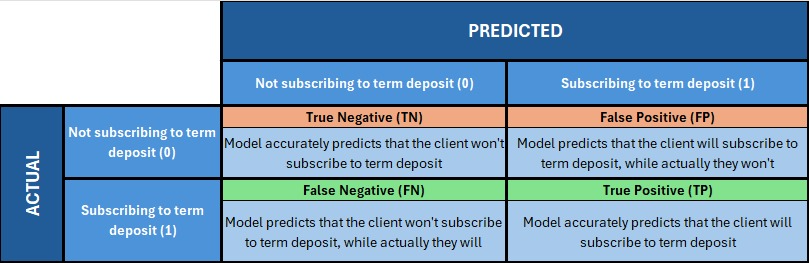

Given the class imbalance in the dataset, the model will be evaluated using metrics beyond simple Accuracy:
* **Precision:** To minimize 'False Positives' (predicting a customer will subscribe when they won't), ensuring call resources are not wasted.
* **Recall:** To minimize 'False Negatives' (missing out on customers who actually would have subscribed), preventing opportunity loss.
* **F1-Score:** To find the optimal balance between Precision and Recall.
* **ROC-AUC:** To measure the model's overall ability to distinguish between the two classes.

# **Data Understanding**

In [ ]:
# Library

import pandas as pd
import numpy as np
import math
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,StratifiedKFold,train_test_split, cross_val_score, cross_validate, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import shap
import pickle

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [2]:
# Load our banking campaign dataset
df = pd.read_csv('bank-additional-full.csv', sep=';', encoding='utf-8')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



## 1. Attribute Information

The dataset consists of 20 independent features and 1 target variable, categorized into client data, campaign details, socio-economic factors, and the target.

**A. Bank Client Data**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **age** | Age of the client | Numeric | 18, 30, 50, etc. |
| **job** | Type of job | Categorical | 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown' |
| **marital** | Marital status | Categorical | 'divorced', 'married', 'single', 'unknown' |
| **education** | Level of education | Categorical | 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown' |
| **default** | Has credit in default? | Categorical | 'no', 'yes', 'unknown' |
| **housing** | Has housing loan? | Categorical | 'no', 'yes', 'unknown' |
| **loan** | Has personal loan? | Categorical | 'no', 'yes', 'unknown' |

**B. Last Contact Information (Current Campaign)**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **contact** | Contact communication type | Categorical | 'cellular', 'telephone' |
| **month** | Last contact month of year | Categorical | 'jan', 'feb', ..., 'nov', 'dec' |
| **day_of_week** | Last contact day of the week | Categorical | 'mon', 'tue', 'wed', 'thu', 'fri' |
| **duration** | Last contact duration in seconds | Numeric | **Note:** Known only after call. Discard for realistic prediction models. |

**C. Other Attributes (Previous Campaigns)**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **campaign** | Number of contacts during this campaign | Numeric | 1, 2, 3, ... (includes last contact) |
| **pdays** | Days since last contact from previous campaign | Numeric | 999 means client was not previously contacted |
| **previous** | Number of contacts before this campaign | Numeric | 0, 1, 2, ... |
| **poutcome** | Outcome of the previous marketing campaign | Categorical | 'failure', 'nonexistent', 'success' |

**D. Socio-Economic Context Attributes**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **emp.var.rate** | Employment variation rate (quarterly) | Numeric | Indicator of economic health |
| **cons.price.idx** | Consumer price index (monthly) | Numeric | Measure of inflation |
| **cons.conf.idx** | Consumer confidence index (monthly) | Numeric | Consumer sentiment indicator |
| **euribor3m** | Euribor 3 month rate (daily) | Numeric | Interbank lending rate |
| **nr.employed** | Number of employees (quarterly) | Numeric | Labor market indicator |

**E. Target Variable**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **y** | Has the client subscribed to a term deposit? | Binary | 'yes' (1), 'no' (0) |

---

## 2. Data Condition: Class Balance Analysis

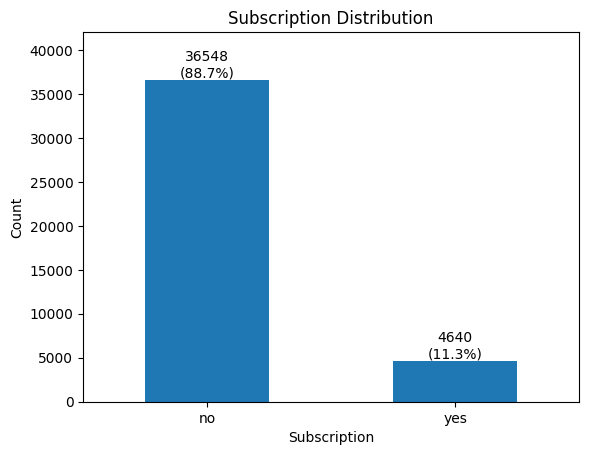

In [3]:
# Count values
counts = df['y'].value_counts()
total = len(df)

# Plot
ax = counts.plot(kind='bar')

# Add labels (count + percentage)
for i, val in enumerate(counts):
    percentage = val / total * 100
    ax.text(i, val, f'{val}\n({percentage:.1f}%)', 
            ha='center', va='bottom')
    
# Add space above bars
ax.set_ylim(0, max(counts) * 1.15)

plt.title('Subscription Distribution')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Status: Highly Imbalanced**
An analysis of the target variable `y` reveals a significant class imbalance:
*   **Class 'no' (Majority):** ~89% 
*   **Class 'yes' (Minority):** ~11%

**What This Means for Modeling:**
* **Accuracy** will not be used as a metric due to class imbalance (a model would predict "no" with 89% accuracy and might ignore the minority class of 'yes').
* **Precision**, **Recall**, **F1-Score**, and **ROC-AUC** metrics will be used to ensure the minority class is captured.
* **Resampling** (SMOTE, Random Under-sampling, etc.) must be used.

## 3. Categorical

### A. Descriptive Statistics

In [4]:
# Descriptive Statistics for Categorical Features
print("\n=== Descriptive Statistics for Categorical Features ===")
df.describe(include=['object'])


=== Descriptive Statistics for Categorical Features ===


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


### B. Distribution of Categorical Features

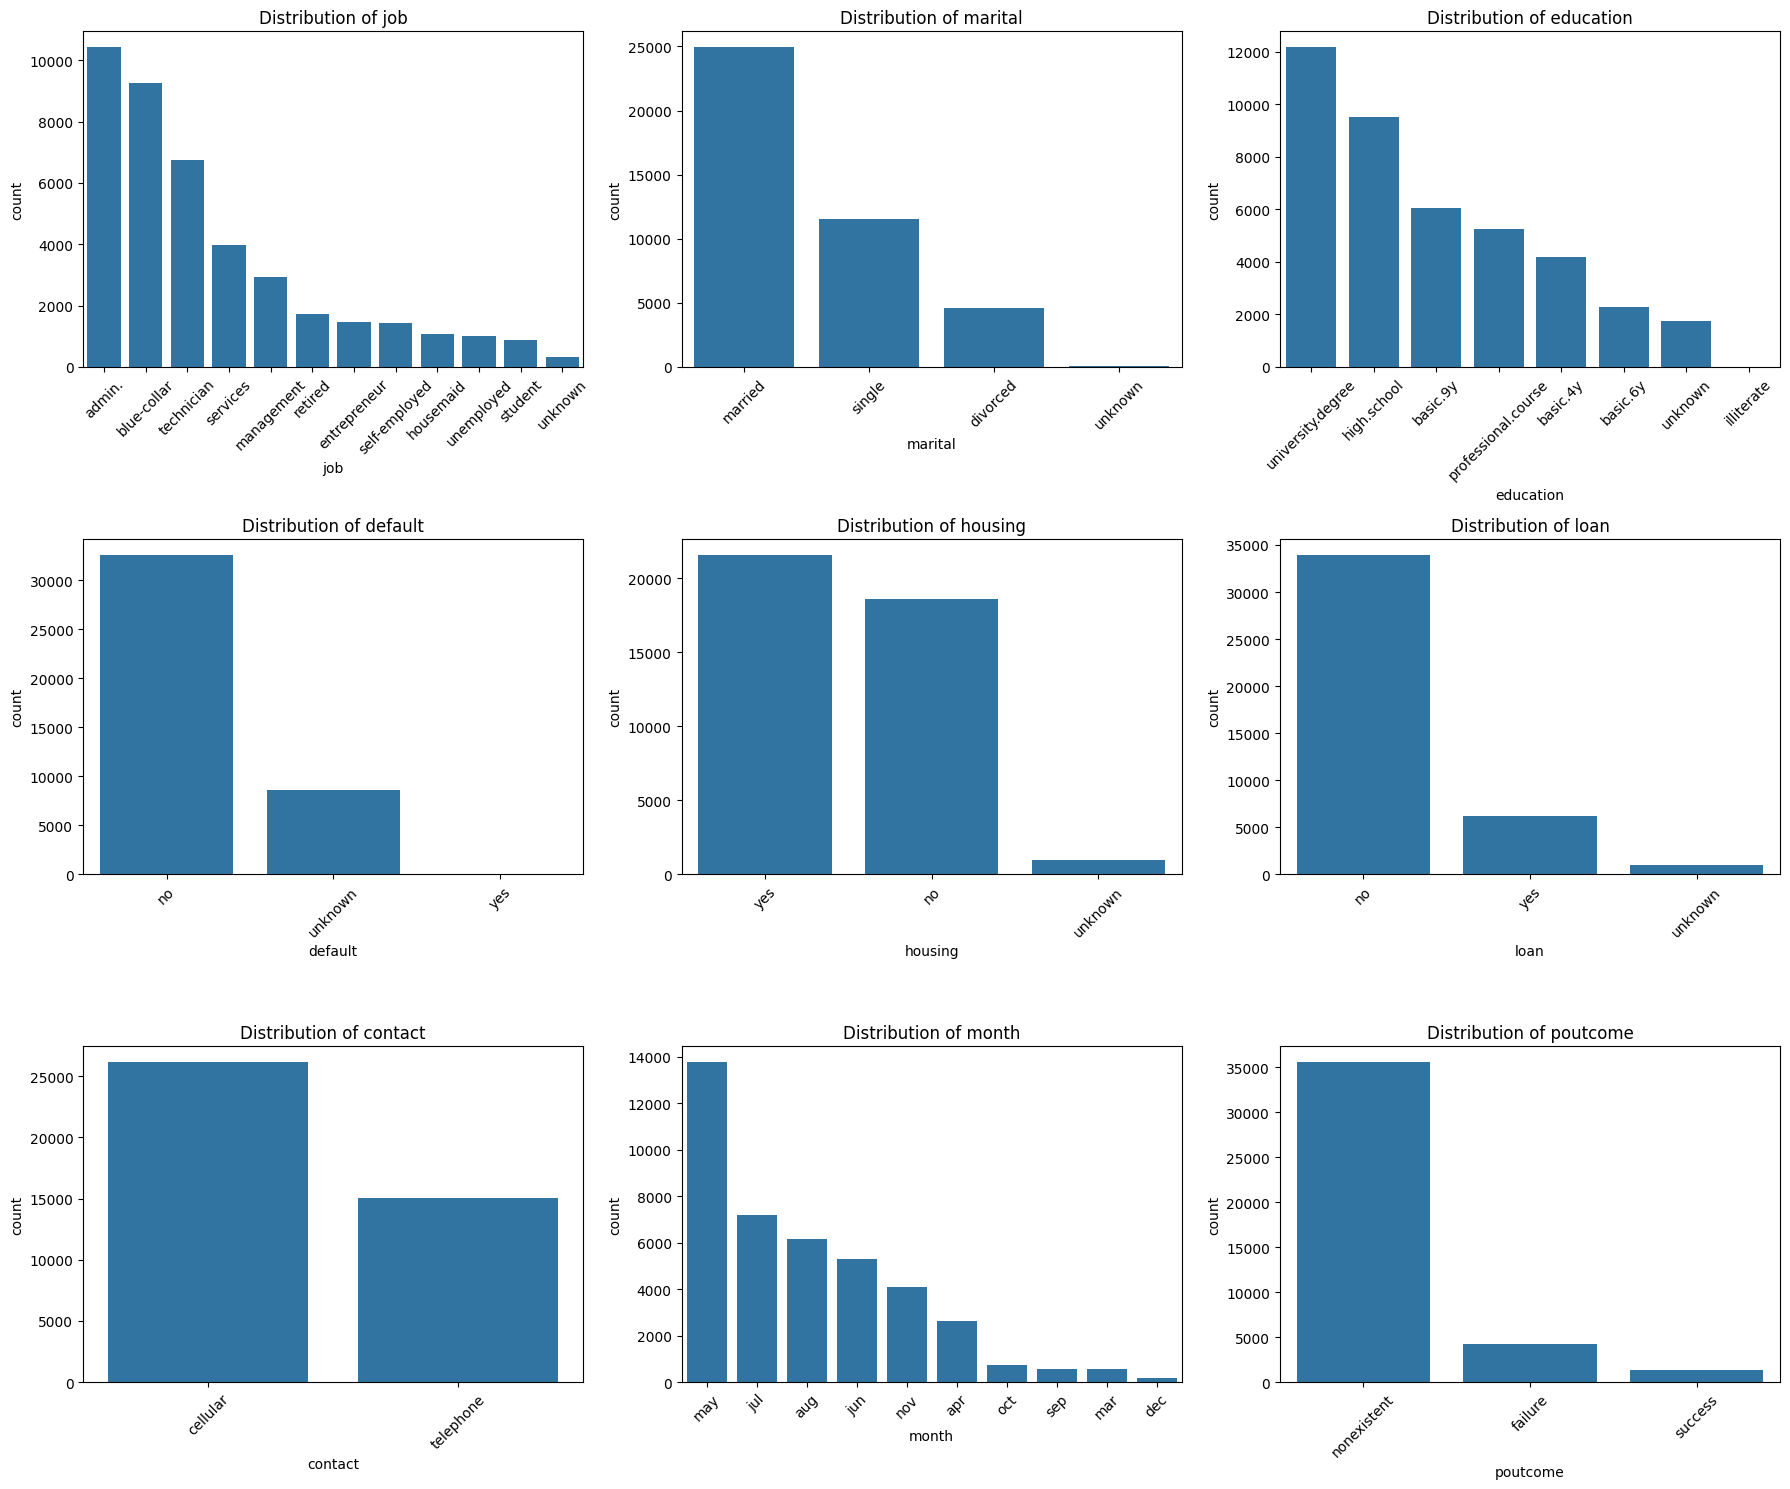

In [5]:
# Select categorical features (excluding target)
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
n = len(categorical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)

    # Order by frequency
    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

## 4. Numerical

#### A. Descriptive Statistics

In [6]:
# Descriptive Statistics for Numerical Features
print("\n=== Descriptive Statistics for Numerical Features ===")
df.describe(include=['int64', 'float64'])


=== Descriptive Statistics for Numerical Features ===


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


#### B. Distribution of Numerical Features
**Client Attributes**

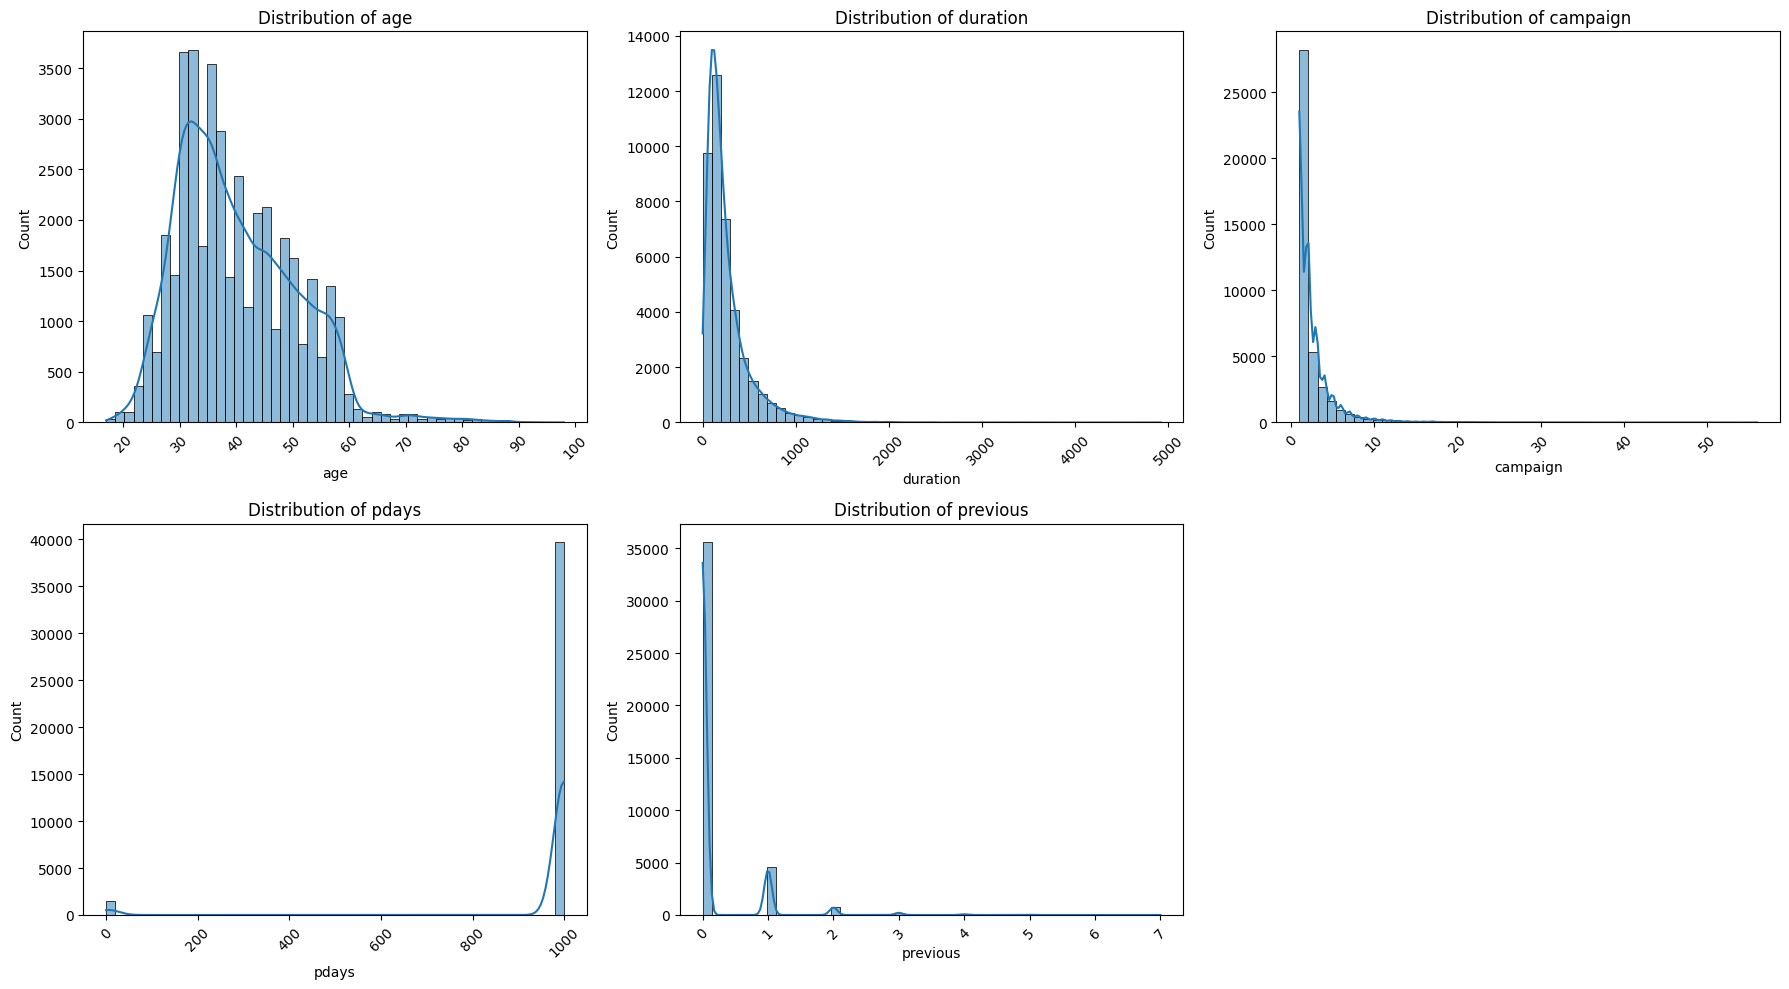

In [7]:
# Select numerical features (attributes)
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']

n = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(data=df, x=col, kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

**Socio-Economic**

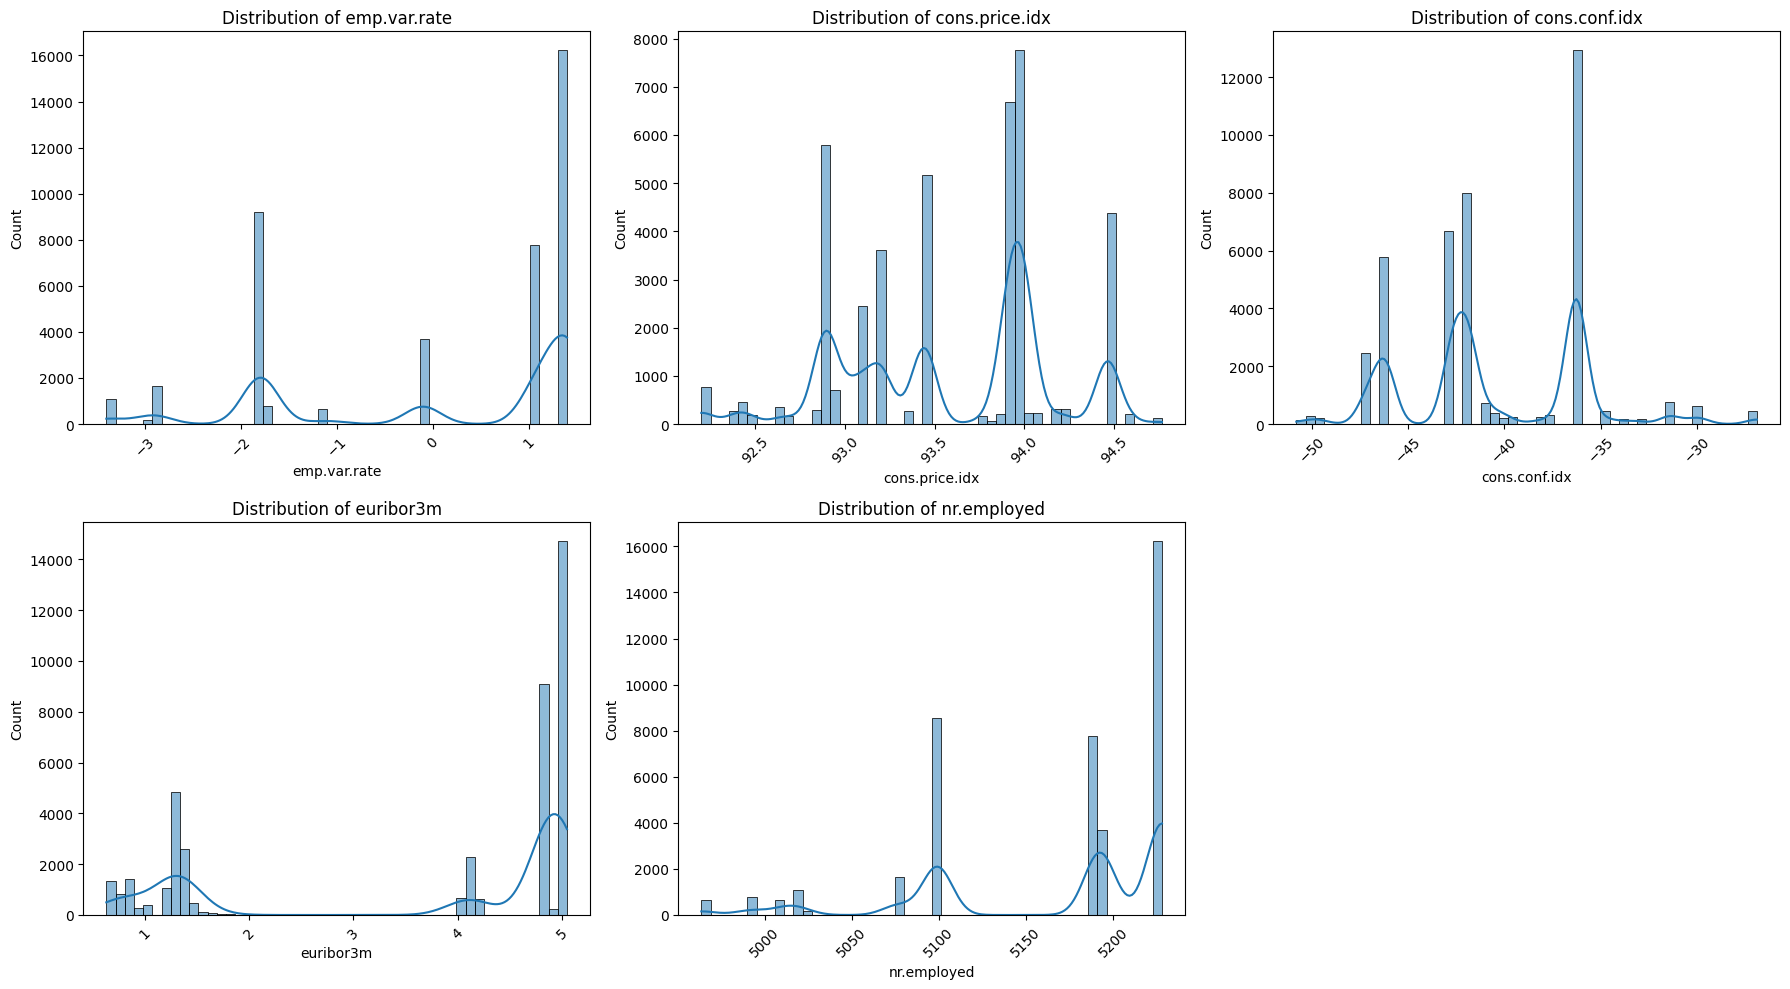

In [8]:
# Select numerical features (socio-economic attributes)
numerical_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

n = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(data=df, x=col, kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

# **Data Preprocessing**

## 1. Data Cleaning

### Copy Dataset for Cleaning

In [9]:
df_clean = df.copy()

### Display Basic Information

In [10]:
print("Dataset Shape:", df_clean.shape)
print("\nMissing Values (Standard NaNs):")
print(df_clean.isnull().sum())
print("\nData Types:")
print(df_clean.dtypes)

Dataset Shape: (41188, 21)

Missing Values (Standard NaNs):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64


*Interpretation:*
We check for standard NaN values. However, in this dataset missing values are often recorded as the string `'unknown'` rather than nulls though their exact nature will be addressed later. We also verify data types to ensure numerical columns are correctly identified.

### Checking & Handling Duplicate Rows

In [11]:
# Check for duplicates
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop duplicates
if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed successfully.")

print("New Dataset Shape:", df_clean.shape)

Number of duplicate rows: 12
Duplicates removed successfully.
New Dataset Shape: (41176, 21)


Interpretation:
We identify and remove exact duplicate rows to ensure each customer contact record is unique, preventing the model from over-learning specific identical patterns.

### Checking and Handling 'Unknown' Values

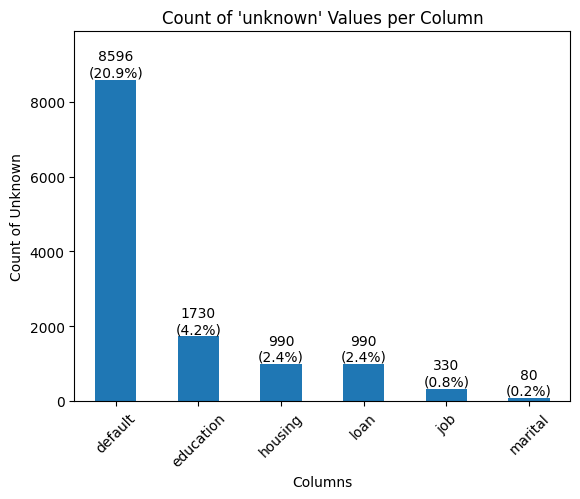

In [12]:
unknown_values = (df_clean == 'unknown').sum()

# Filter out columns with no unknown values
unknown_values = unknown_values[unknown_values > 0].sort_values(ascending=False)

# Plot
plt.figure()
ax = unknown_values.plot(kind='bar')

# Add space above bars
ax.set_ylim(0, max(unknown_values) * 1.15)

# Add Labels
total = len(df_clean)
for i, val in enumerate(unknown_values):
    percentage = val / total * 100
    ax.text(i, val, f'{val}\n({percentage:.1f}%)',
            ha='center', va='bottom')

plt.title("Count of 'unknown' Values per Column")
plt.xlabel('Columns')
plt.ylabel('Count of Unknown')

plt.xticks(rotation=45)
plt.show()

Interpretation: Columns like `education`, `job`, and `housing` often have "unknown" values, with the highest in `default`. It is interesting to note how `housing` and `loan` have the same count of unknowns. We should be careful how to handle these unknowns to not lose any meaningful information.

#### A. Default
20.9% of all data have unknown in `default` feature. Due to the size of it, this meant meaningful data for the model. In banking, if a person's credit default history is unknown, it might mean they have no credit history or didn't disclose it. To test the hypothesis that it simply means they have no credit history, let's crosstab them to housing and loan features.

In [13]:
# How default status relates to housing loan
pd.crosstab(df_clean['default'], df_clean['housing'])

housing,no,unknown,yes
default,,,
no,14608,763,17206
unknown,4005,227,4364
yes,2,0,1


In [14]:
# How default status relates to loan ownership
pd.crosstab(df_clean['default'], df_clean['loan'])

loan,no,unknown,yes
default,,,
no,26838,763,4976
unknown,7097,227,1272
yes,3,0,0


Interpretation: Having no credit would mean not having loan or housing loan. But since from this crosstab they are a mix of yes or no, it means that some indeed refuse to answer about their credit history, or it could just be a missing data collected from the bank. Nevertheless, we're still going to 'unknown' as its own distinct category.

As mentioned before, it is interesting to see the number of clients in 'unknown' from `housing` and `loan` is the same even in this crosstab, which we will cover next.

#### B. Housing and Loan
From previous crosstab, it seems like the client in 'unknown' from `housing` and `loan` might be the same people.

In [15]:
pd.crosstab(df_clean['loan'], df_clean['housing'])

housing,no,unknown,yes
loan,,,
no,16058,0,17880
unknown,0,990,0
yes,2557,0,3691


Interpretation: They are in fact the same people. Because the missingness might be a pattern, we keep unknowns in `housing` and `loan` as its own distinct category.

#### C. Education and Job
People with similar jobs often have similar education levels. With this information, we can impute unknown education with the mode education level for that specific job type, and vice versa.

In [16]:
# Group-based Imputation for 'education'
# Calculate the most common education for each job
edu_mode_per_job = df_clean[df_clean['education'] != 'unknown'].groupby('job')['education'].agg(lambda x: x.mode()[0]).to_dict()

def impute_education(row):
    if row['education'] == 'unknown':
        # Return the most common education for that person's job
        return edu_mode_per_job.get(row['job'], 'university.degree') # fallback to global mode
    return row['education']

df_clean['education'] = df_clean.apply(impute_education, axis=1)

print(f"Unknowns remaining in education: {(df_clean['education'] == 'unknown').sum()}")

# Group-based Imputation for 'job'
# Calculate the most common job for each education level
job_mode_per_edu = df_clean[df_clean['job'] != 'unknown'].groupby('education')['job'].agg(lambda x: x.mode()[0]).to_dict()

# Apply the mapping
def impute_job(row):
    if row['job'] == 'unknown':
        # Return the most common job for that person's education level
        return job_mode_per_edu.get(row['education'], 'admin.') # fallback to global mode
    return row['job']

df_clean['job'] = df_clean.apply(impute_job, axis=1)

print(f"Unknowns remaining in job: {(df_clean['job'] == 'unknown').sum()}")

Unknowns remaining in education: 0
Unknowns remaining in job: 0


#### D. Marital
Since only 0.2% of the data is missing for `marital` status, the impact of a simple fix is negligible. We can simply impute it with the mode of the column.

In [17]:
# Simple Mode Imputation for 'marital'
marital_mode = df_clean[df_clean['marital'] != 'unknown']['marital'].mode()[0]
df_clean['marital'] = df_clean['marital'].replace('unknown', marital_mode)
print(f"Unknowns remaining in marital: {(df_clean['marital'] == 'unknown').sum()}")

Unknowns remaining in marital: 0


### Checking & Handling Outliers

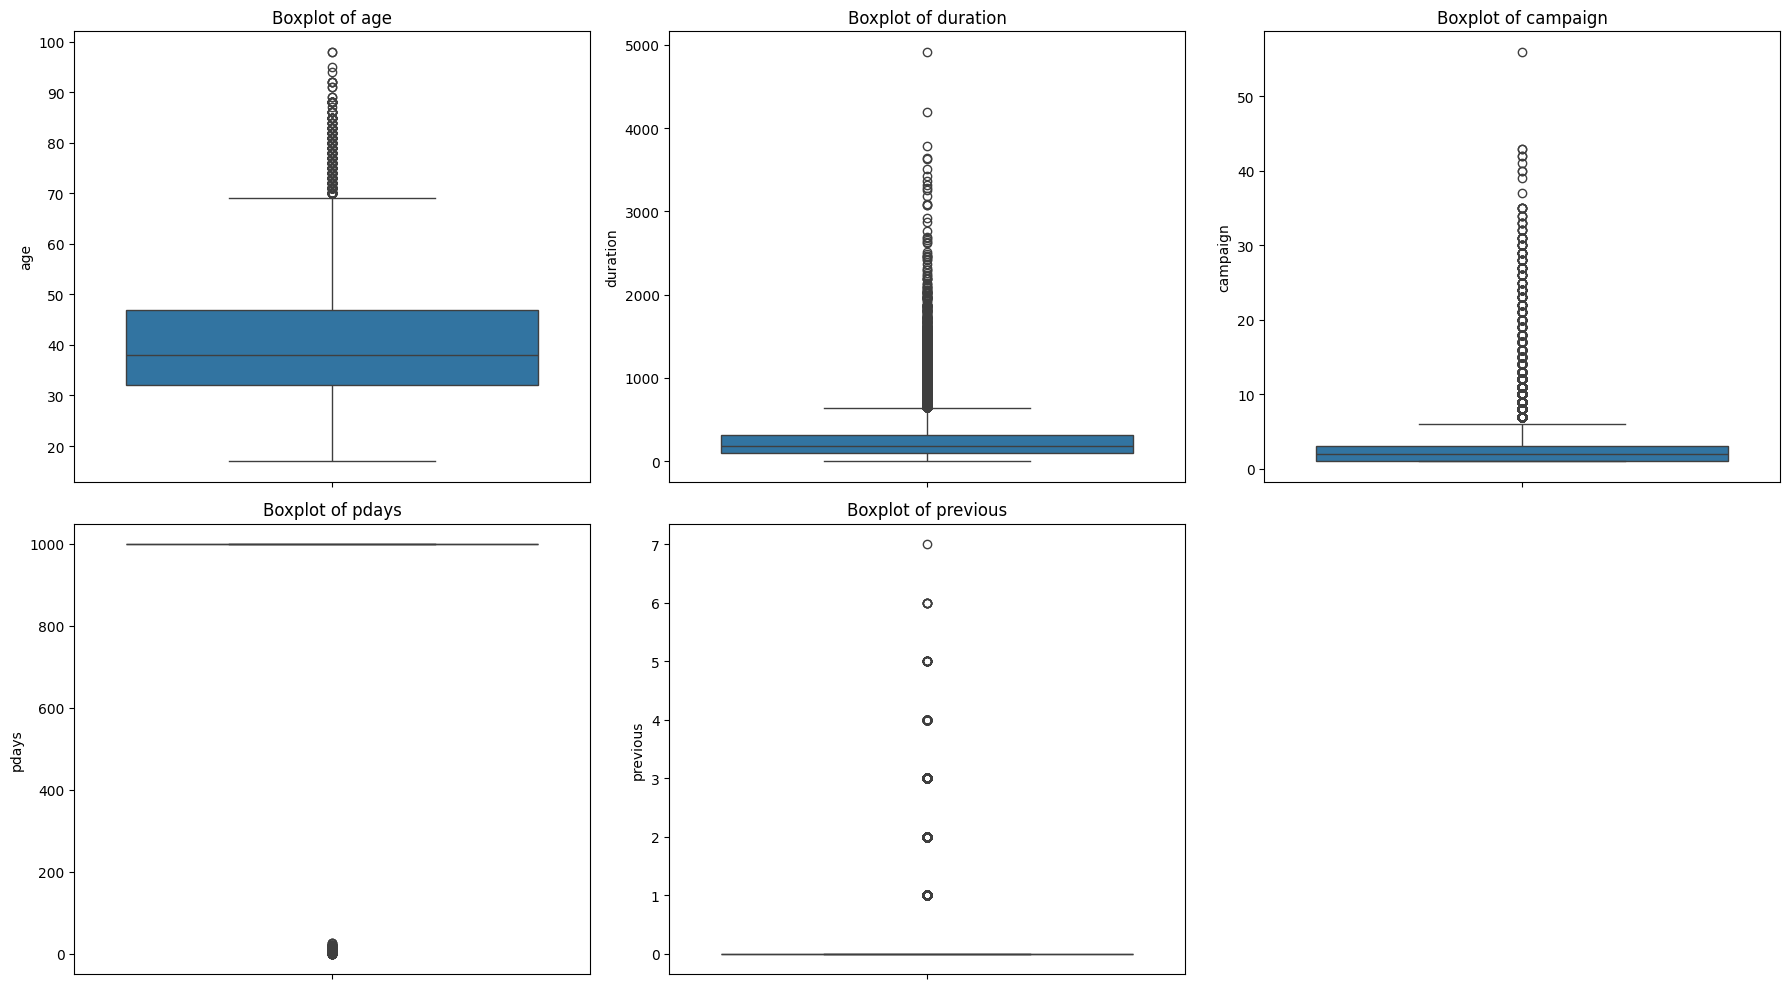


=== Outlier Detection (IQR method) ===
age: 468 outliers (1.14%)
duration: 2963 outliers (7.19%)
campaign: 2406 outliers (5.84%)
   Max campaign: 56 - possible data entry error or extreme case.
pdays: 1515 outliers (3.68%)
   pdays = 999 indicates 'never contacted before'. Count: 39661
previous: 5625 outliers (13.66%)


In [18]:
# Numerical Attributes
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Boxplots to detect outliers
n = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Detailed Outlier Analysis using IQR
print("\n=== Outlier Detection (IQR method) ===")
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    if col == 'campaign':
        print(f"   Max campaign: {df_clean['campaign'].max()} - possible data entry error or extreme case.")
    if col == 'pdays':
        print(f"   pdays = 999 indicates 'never contacted before'. Count: {(df_clean['pdays'] == 999).sum()}")

Interpretation:
The value 999 is an outlier that would confuse distance-based algorithms (like KNN or SVM). By converting it into a binary feature (Contacted vs. Not Contacted), we preserve the logic without the numerical distortion.

#### A. Age
Ages 85–98 are real, valid people, so not errors. There are just very few of them. Capping at the 99th percentile preserves the data without letting extreme elderly ages distort the model.

In [19]:
# Cap age at 99th percentile
age_cap = df_clean['age'].quantile(0.99)
df_clean['age'] = df_clean['age'].clip(upper=age_cap)
df_clean['age'].describe()

count    41176.000000
mean        39.955144
std         10.176254
min         17.000000
25%         32.000000
50%         38.000000
75%         47.000000
max         71.000000
Name: age, dtype: float64

#### B. Duration
Duration has outliers but it will not matter since it will be dropped before modeling. So, we leave it as is for EDA purposes, then drop it after.

#### C. Campaign
Someone being called 56 times is almost certainly a data entry error or extreme edge case. Capping at the 99th percentile is the right call here.

In [20]:
# Cap campaign at 99th percentile
campaign_cap = df_clean['campaign'].quantile(0.99)
df_clean['campaign'] = df_clean['campaign'].clip(upper=campaign_cap)
df_clean['campaign'].describe()

count    41176.000000
mean         2.500291
std          2.301416
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
Name: campaign, dtype: float64

#### D. Days since Last Contacted from Previous Campaign (`pdays`)
Treatment for this feature will be carried out in feature engineering.

#### E. Number of Contacts before this Campaign (`previous`)
IQR flags this because most of them are 0, making IQR = 0. But values of 1–7 are completely legitimate: a client was contacted up to 7 times before. This is not an outlier problem, it's just a heavily zero-inflated distribution. Conclusion: Leave it alone.

## 2. Features Engineering & Features Selection

### A. Categorical Feature Engineering: Grouping & Binning

High-cardinality features like `job` and `education` create noise. Research shows that grouping these into broader categories improves model generalization.

In [21]:
def engineer_categorical(df_clean):
    # 1. Simplify Jobs: Group by similar socio-economic status/risk
    job_map = {
        'admin.': 'white-collar', 'management': 'white-collar', 'entrepreneur': 'white-collar',
        'blue-collar': 'blue-collar', 'services': 'blue-collar', 'technician': 'blue-collar',
        'retired': 'retired', 'student': 'student', 'unemployed': 'unemployed',
        'self-employed': 'self-employed', 'housemaid': 'blue-collar', 'unknown': 'unknown'
    }
    df_clean['job_category'] = df_clean['job'].map(job_map)

    # 2. Ordinal Encoding for Education
    # Education has a logical order of value/potential income
    edu_map = {
        'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
        'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 2 # Median
    }
    df_clean['education_level'] = df_clean['education'].map(edu_map)

    # 3. Simplify Marital Status
    # 'Single' and 'Divorced' often behave similarly compared to 'Married' in savings behavior
    df_clean['is_married'] = df_clean['marital'].apply(lambda x: 1 if x == 'married' else 0)
    
    return df_clean

df_clean = engineer_categorical(df_clean)

### B. Numerical Feature Engineering: Time & Contact

The features `pdays` and `age` require specific transformations to be useful.

In [22]:
def engineer_numerical(df_clean):
    # 1. Age Binning: Life stages influence financial decisions
    # Groups: Young, Adult, Senior, Elderly
    df_clean['age_bin'] = pd.cut(df_clean['age'], bins=[0, 25, 40, 60, 100], labels=['Student_Age', 'Young_Adult', 'Adult', 'Senior'])

    # 2. pdays: 999 means "never contacted".
    # This is a huge outlier. Let's create a binary flag and a log transform for the rest.
    df_clean['never_contacted'] = (df_clean['pdays'] == 999).astype(int)
    # Replace 999 with a value that doesn't skew distributions
    df_clean['pdays'] = df_clean['pdays'].replace(999, 0)

    # 3. Campaign contact frequency
    # High frequency contacts often lead to "marketing fatigue"
    df_clean['campaign_intensity'] = df_clean['campaign'].apply(lambda x: 'high' if x > 3 else 'low')

    return df_clean

df_clean = engineer_numerical(df_clean)

### C. Socio-Economic Indicators (The "Macro" Features)

The Bank Marketing dataset is unique because it includes quarterly economic indicators. These are often the strongest predictors

In [23]:
def engineer_economic(df_clean):
    # 1. Confidence vs. Price interaction
    # If prices are high and confidence is low, people save more (term deposits)
    # Since cons.price.idx and cons.conf.idx are on different scales (positives and negatives), we can capture the interaction
    # by subtracting confidence from price
    # High prices + very negative confidence → large difference → people are more likely to save in term deposits
    df_clean['price_conf_index'] = df_clean['cons.price.idx'] - df_clean['cons.conf.idx']
    
    # 2. Employment variation rate as a binary (Growing vs. Shrinking economy)
    df_clean['economy_growing'] = df_clean['emp.var.rate'].apply(lambda x: 1 if x > 0 else 0)
    
    return df_clean

df_clean = engineer_economic(df_clean)

In [24]:
# Check the new feature price_conf_index
# The result is always positive and ranges from ~119 to ~145 → "how far apart are price levels from consumer sentiment"
df_clean['price_conf_index'].describe()

count    41176.000000
mean       134.078583
std          4.629809
min        119.331000
25%        130.394000
50%        135.200000
75%        136.618000
max        145.567000
Name: price_conf_index, dtype: float64

### D. Binary Target
Lastly, we want to make our target into binary column to allow mathematical calculation such as conversion rate.

In [25]:
# Turning our target variable into binary
df_clean['y'] = df_clean['y'].replace({'yes': 1, 'no': 0})

# However, we want to have yes and no as readable legends in charts. So we we make a label for y
df_clean['y_label'] = df_clean['y'].map({1: 'yes', 0: 'no'})

## 3. Save Clean Dataframe into CSV

In [26]:
# Save the clean dataframe to be used in tableau dashboard
df_clean.to_csv('bank-additional-full-clean.csv', index=False)

In [27]:
df_clean

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_category,education_level,is_married,age_bin,never_contacted,campaign_intensity,price_conf_index,economy_growing,y_label
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,1,1,Adult,1,low,130.394,1,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,4,1,Adult,1,low,130.394,1,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,4,1,Young_Adult,1,low,130.394,1,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,white-collar,2,1,Young_Adult,1,low,130.394,1,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,4,1,Adult,1,low,130.394,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,71,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,retired,5,1,Senior,1,low,145.567,0,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,blue-collar,5,1,Adult,1,low,145.567,0,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,retired,6,1,Adult,1,low,145.567,0,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,blue-collar,5,1,Adult,1,low,145.567,0,yes


# **Exploratory Data Analysis**

## 1. Customer Demographics

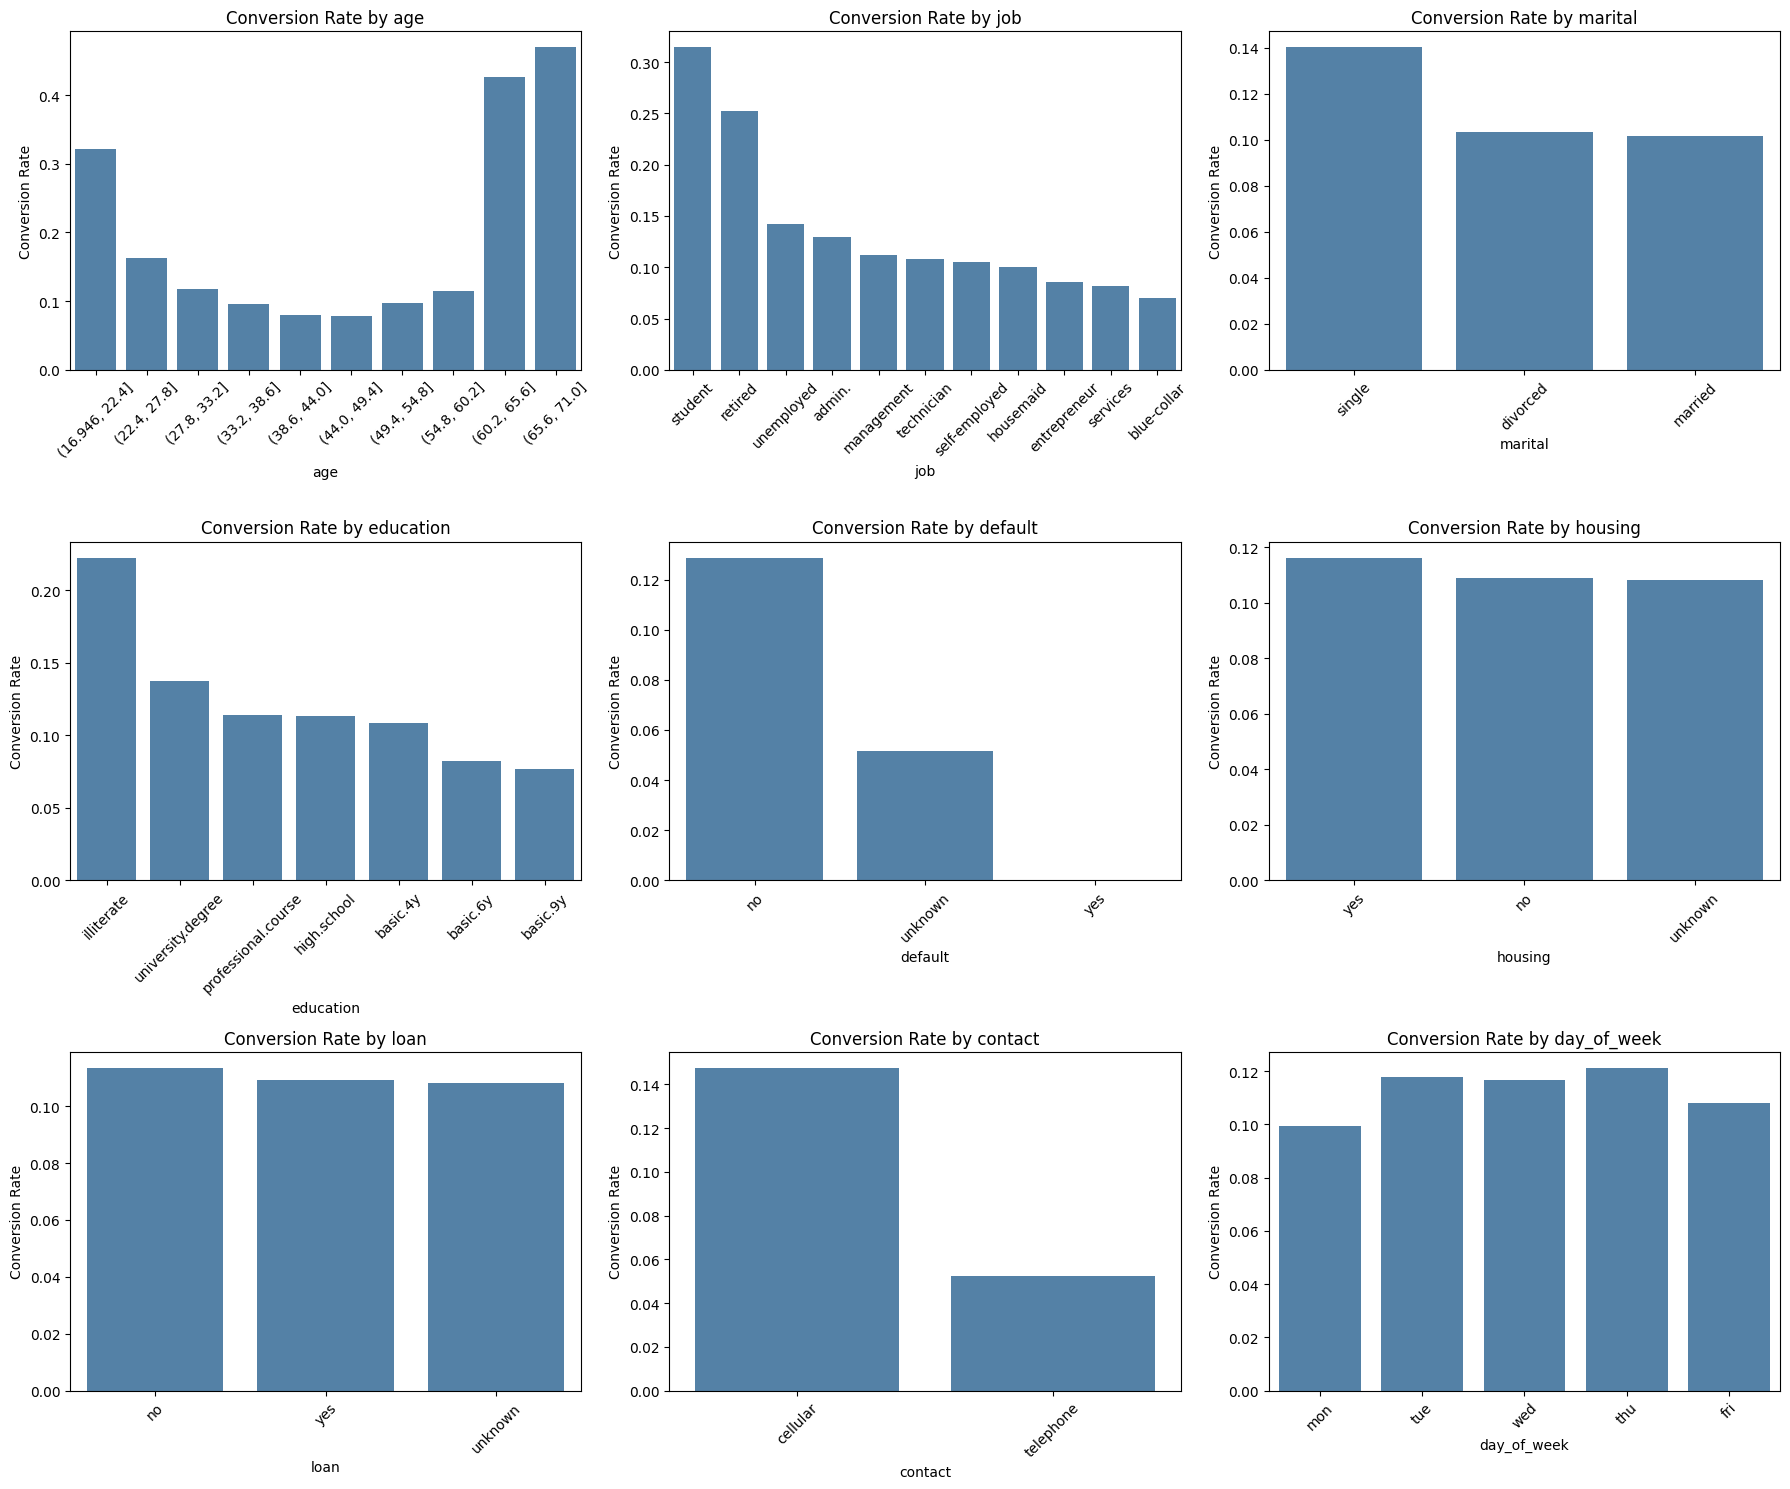

In [28]:
def plot_conversion_rates(df, features, target='y', bins=10):
    n = len(features)
    cols = 3  # number of plots per row
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 6, rows * 5))

    for i, feature in enumerate(features, 1):
        plt.subplot(rows, cols, i)

        if feature == 'age':
            # Bin age into groups
            age_bins = pd.cut(df[feature], bins=bins)
            rate = df.groupby(age_bins)[target].mean()
            x_labels = [str(interval) for interval in rate.index]
        elif feature == 'day_of_week':
            # Order days of week
            order = ['mon', 'tue', 'wed', 'thu', 'fri']
            rate = df.groupby(feature)[target].mean().reindex(order)
            x_labels = rate.index.astype(str)
        else:
            rate = df.groupby(feature)[target].mean().sort_values(ascending=False)
            x_labels = rate.index.astype(str)

        sns.barplot(x=x_labels, y=rate.values, color='steelblue')

        plt.title(f'Conversion Rate by {feature}')
        plt.xticks(rotation=45)
        plt.ylabel('Conversion Rate')
        plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

features = ['age', 'job', 'marital', 'education', 'default', 
            'housing', 'loan', 'contact', 'day_of_week']
plot_conversion_rates(df_clean, features)

Interpretation: It looks like conversion rate is highest on students and those that are retired. Age group confirms this as well. Those that are illiterate also more prone to term deposit. Marital status does not seem to affect much. In financial status, those that have not default in credit is more likely to subscribe to term deposit, while housing and personal loan display minimal variation in conversion rate. Cellular contact has a much higher conversion rate than telephone. Lastly, Thursday/Tuesday outperform any day, with Mondays the lowest.

## 2. Deeper Look into Job Conversion Rate

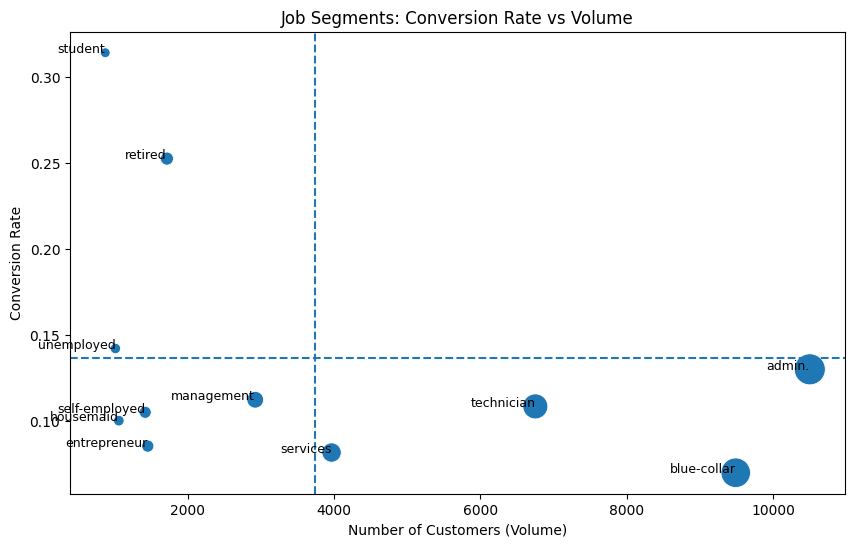

In [29]:
# Create data for volume and conversion rate
job_summary = df_clean.groupby('job').agg(
    volume=('y', 'count'),
    conversion_rate=('y', 'mean')
).reset_index()

# Calculate averages
avg_volume = job_summary['volume'].mean()
avg_rate = job_summary['conversion_rate'].mean()

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=job_summary,
    x='volume',
    y='conversion_rate',
    size='volume',
    sizes=(50, 500),
    legend=False
)

# Add labels
for i in range(len(job_summary)):
    plt.text(
        job_summary['volume'][i],
        job_summary['conversion_rate'][i],
        job_summary['job'][i],
        fontsize=9,
        ha='right'
    )

# Add quadrant lines
plt.axvline(avg_volume, linestyle='--')
plt.axhline(avg_rate, linestyle='--')

plt.title('Job Segments: Conversion Rate vs Volume')
plt.xlabel('Number of Customers (Volume)')
plt.ylabel('Conversion Rate')

plt.show()

Interpretation: Students and retired customers exhibit higher conversion rates, making them high-efficiency targets. Meanwhile, administrative and technician roles contribute larger customer volumes, making them important for scaling total conversions despite lower individual conversion rates.

## 3. Campaign Timing and Seasonality

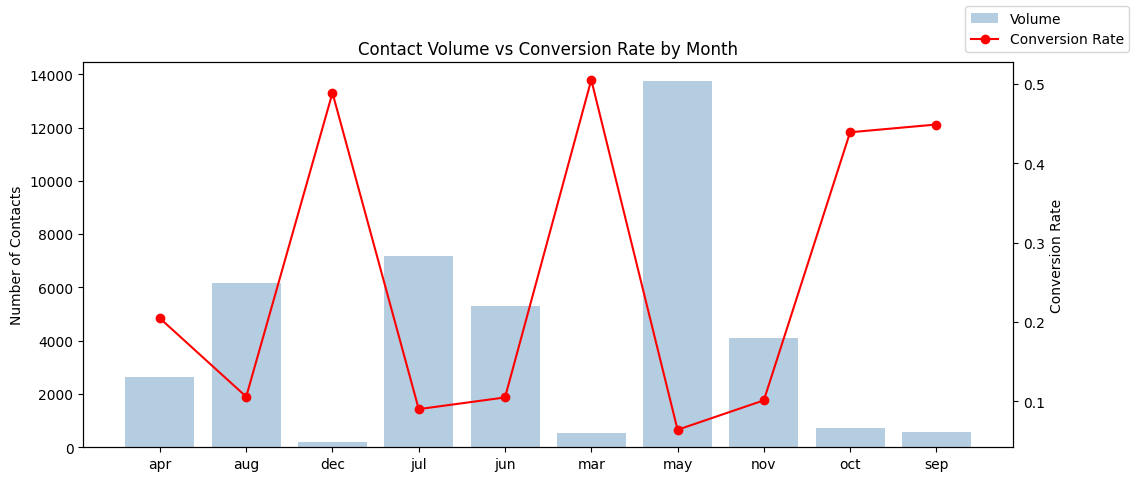

In [30]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar: volume
month_counts = df_clean.groupby('month', observed=True)['y'].count()
ax1.bar(month_counts.index, month_counts.values, alpha=0.4, color='steelblue', label='Volume')
ax1.set_ylabel('Number of Contacts')

# Line: conversion rate
ax2 = ax1.twinx()
month_rate = df_clean.groupby('month', observed=True)['y'].mean()
ax2.plot(month_rate.index, month_rate.values, color='red', marker='o', label='Conversion Rate')
ax2.set_ylabel('Conversion Rate')

plt.title('Contact Volume vs Conversion Rate by Month')
fig.legend(loc='upper right')
plt.show()

Interpretation: It seems like in the months of March, September, October, and December are the ones with the highest conversion rate, but they're also the ones with small sample size.

## 4. Marketing Campaign Fatigue

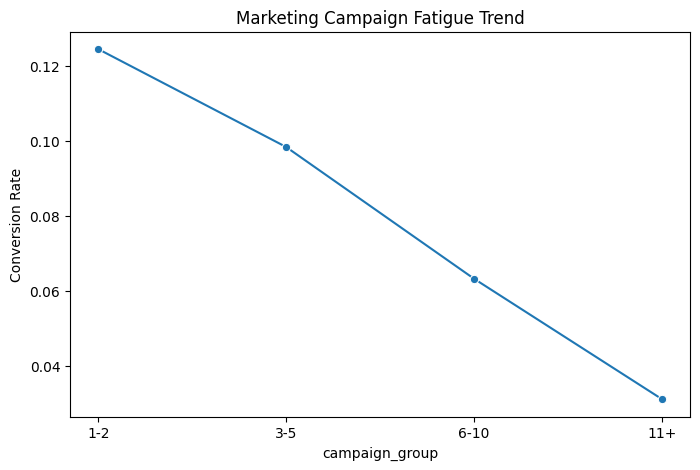

campaign_group
1-2     28202
3-5      9589
6-10     2516
11+       869
Name: count, dtype: int64


In [31]:
# Create bin for more interpretability
df_clean['campaign_group'] = pd.cut(
    df_clean['campaign'],
    bins=[0, 2, 5, 10, 100],
    labels=['1-2', '3-5', '6-10', '11+']
)

# Compute conversion rate
rate = df_clean.groupby('campaign_group', observed=True)['y'].mean().reset_index()

# Plot fatigue chart
plt.figure(figsize=(8,5))
sns.lineplot(x='campaign_group', y='y', data=rate, marker='o')

plt.title('Marketing Campaign Fatigue Trend')
plt.ylabel('Conversion Rate')
plt.show()

# Show sample size of each bin group
counts = df_clean['campaign_group'].value_counts().sort_index()

print(counts)

Interpretation: Conversion rates decrease as the number of contact attempts increases, indicating diminishing returns and potential customer fatigue from repeated calls.

## 5. Previous Campaign Outcome Conversion Rate

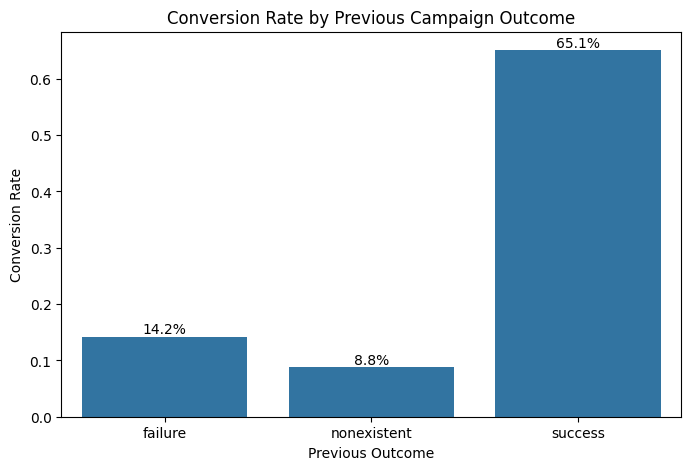

poutcome
nonexistent    35551
failure         4252
success         1373
Name: count, dtype: int64


In [32]:
# Compute conversion rate
rate = df_clean.groupby('poutcome')['y'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(x='poutcome', y='y', data=rate)

# Add % labels
for i, v in enumerate(rate['y']):
    ax.text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')

plt.title('Conversion Rate by Previous Campaign Outcome')
plt.xlabel('Previous Outcome')
plt.ylabel('Conversion Rate')

plt.show()

# Show sample size
print(df_clean['poutcome'].value_counts())

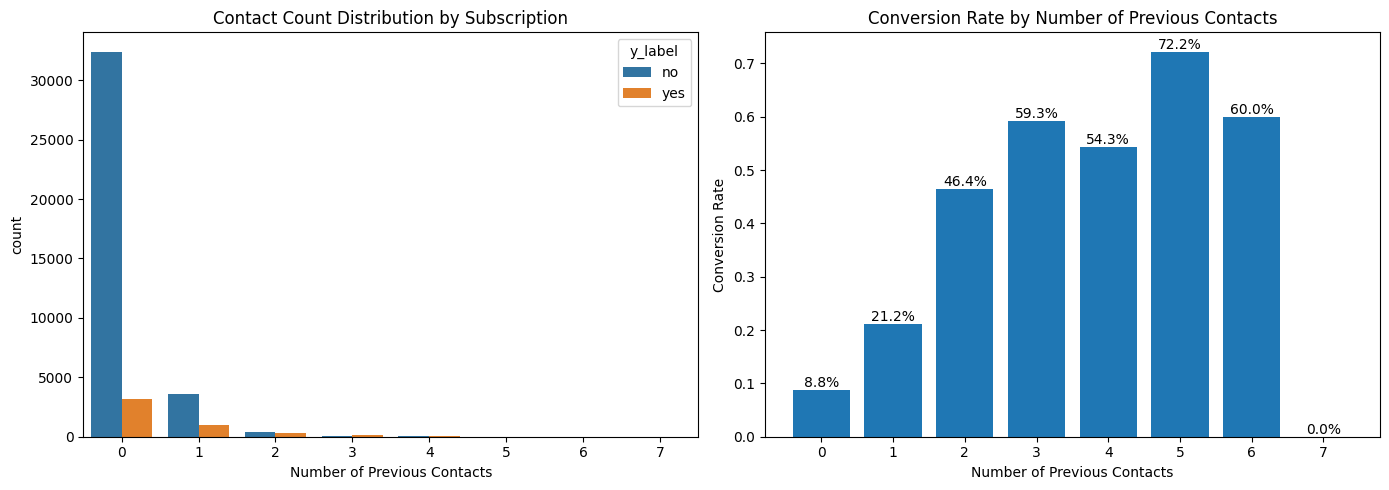

In [33]:
# Compute conversion rate
rate = df_clean.groupby('previous')['y'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.countplot(data=df_clean, x='previous', hue='y_label', ax=axes[0])
axes[0].set_title('Contact Count Distribution by Subscription')
axes[0].set_xlabel('Number of Previous Contacts')

# Conversion rate
axes[1].bar(rate['previous'].astype(str), rate['y'])
for i, v in enumerate(rate['y']):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by Number of Previous Contacts')
axes[1].set_xlabel('Number of Previous Contacts')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: Although the number of people who subscribed to term deposit from previous campaign comparably small, they have really high conversion rate to current campaign as well, especially those who were contacted 3-6 times. This makes them prime targets for future campaigns.

## 6. Duration Feature
We know `duration` causes data leakage but let's see how it matters with our target variable.

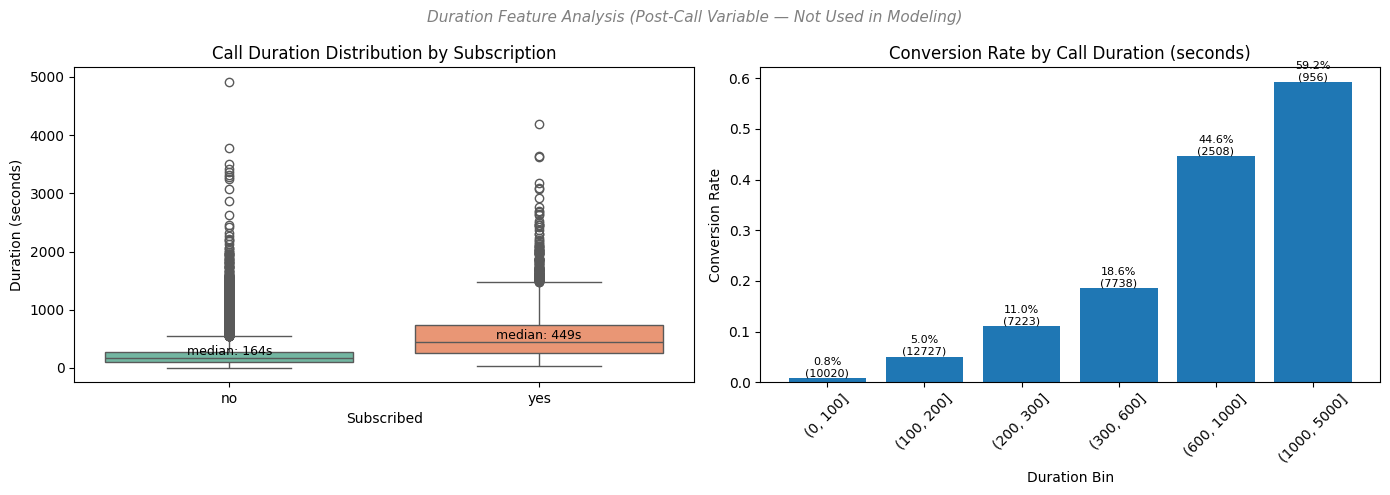

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution by subscription
sns.boxplot(data=df_clean, x='y_label', y='duration', ax=axes[0], palette='Set2')
axes[0].set_title('Call Duration Distribution by Subscription')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Duration (seconds)')

# Add median labels
for i, label in enumerate(['no', 'yes']):
    median = df_clean[df_clean['y_label'] == label]['duration'].median()
    axes[0].text(i, median, f'median: {median:.0f}s', 
                ha='center', va='bottom', fontsize=9)

# Right: Conversion rate by duration bin
df_clean['duration_bin'] = pd.cut(
    df_clean['duration'],
    bins=[0, 100, 200, 300, 600, 1000, 5000]
)
duration_rate = df_clean.groupby('duration_bin', observed=True)['y'].mean()
duration_counts = df_clean.groupby('duration_bin', observed=True)['y'].count()

bars = axes[1].bar(range(len(duration_rate)), duration_rate.values)
axes[1].set_xticks(range(len(duration_rate)))
axes[1].set_xticklabels([str(b) for b in duration_rate.index], rotation=45)
axes[1].set_title('Conversion Rate by Call Duration (seconds)')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xlabel('Duration Bin')

# Add conversion % and sample size labels
for i, (v, n) in enumerate(zip(duration_rate.values, duration_counts.values)):
    axes[1].text(i, v, f'{v*100:.1f}%\n({n})', 
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Duration Feature Analysis (Post-Call Variable — Not Used in Modeling)', 
             fontsize=11, style='italic', color='gray')
plt.tight_layout()
plt.show()

Interpretation: Call duration shows a strong positive relationship with subscription success. The bank made a lot of short, low-quality calls. But, conversion rates increase sharply as call duration increases, with calls longer than 600 seconds achieving significantly higher success rates. However, the majority of calls are short in duration and exhibit very low conversion, suggesting that improving customer engagement during calls may significantly enhance campaign effectiveness.

However, duration is a post-call variable and cannot be used for prediction prior to contact, as it reflects the outcome of the interaction rather than a pre-existing customer characteristic.

**Recommendation:** Improve early-stage engagement to prevent short call drop-offs.

## 7. Correlation Analysis

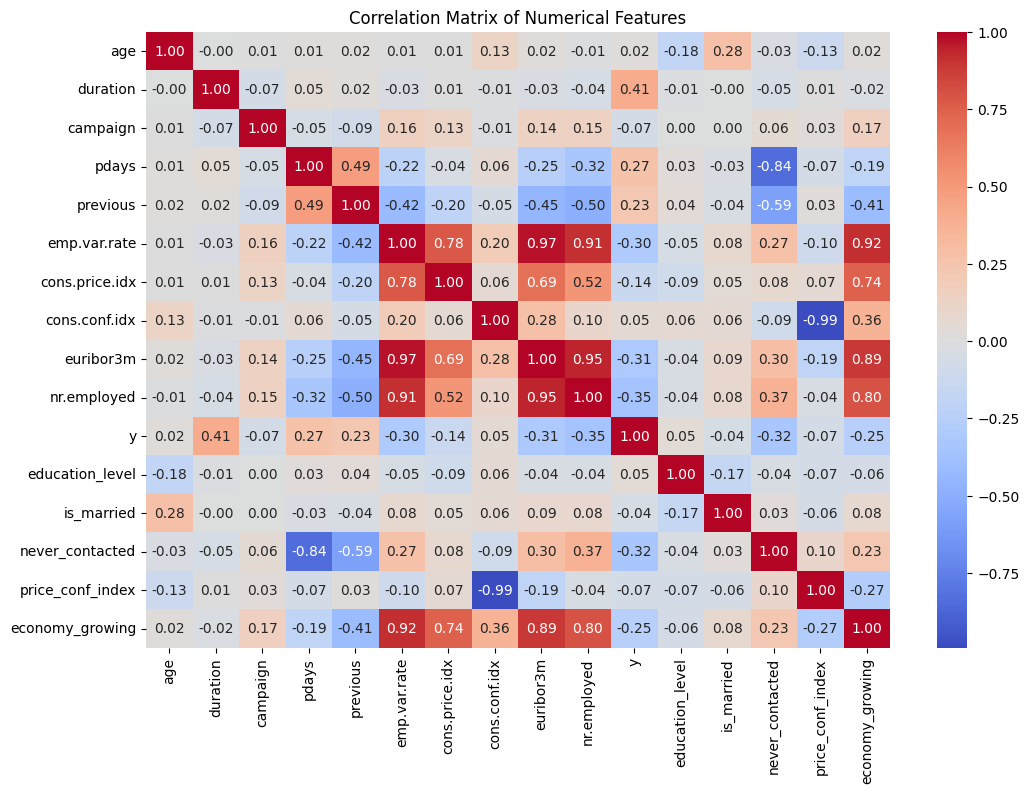

In [35]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Interpretation: The numerical features show strong inter-correlation among the macroeconomic indicators, especially `emp.var.rate`, `euribor3m`, and `nr.employed`, suggesting overlapping economic information. Their relationships with the target are moderate, with higher employment and interest-rate indicators associated with lower subscription likelihood. `duration` shows the strongest positive association with subscription, but it is a post-call feature and should be treated cautiously due to leakage.

## 8. Socio-Economic Impact

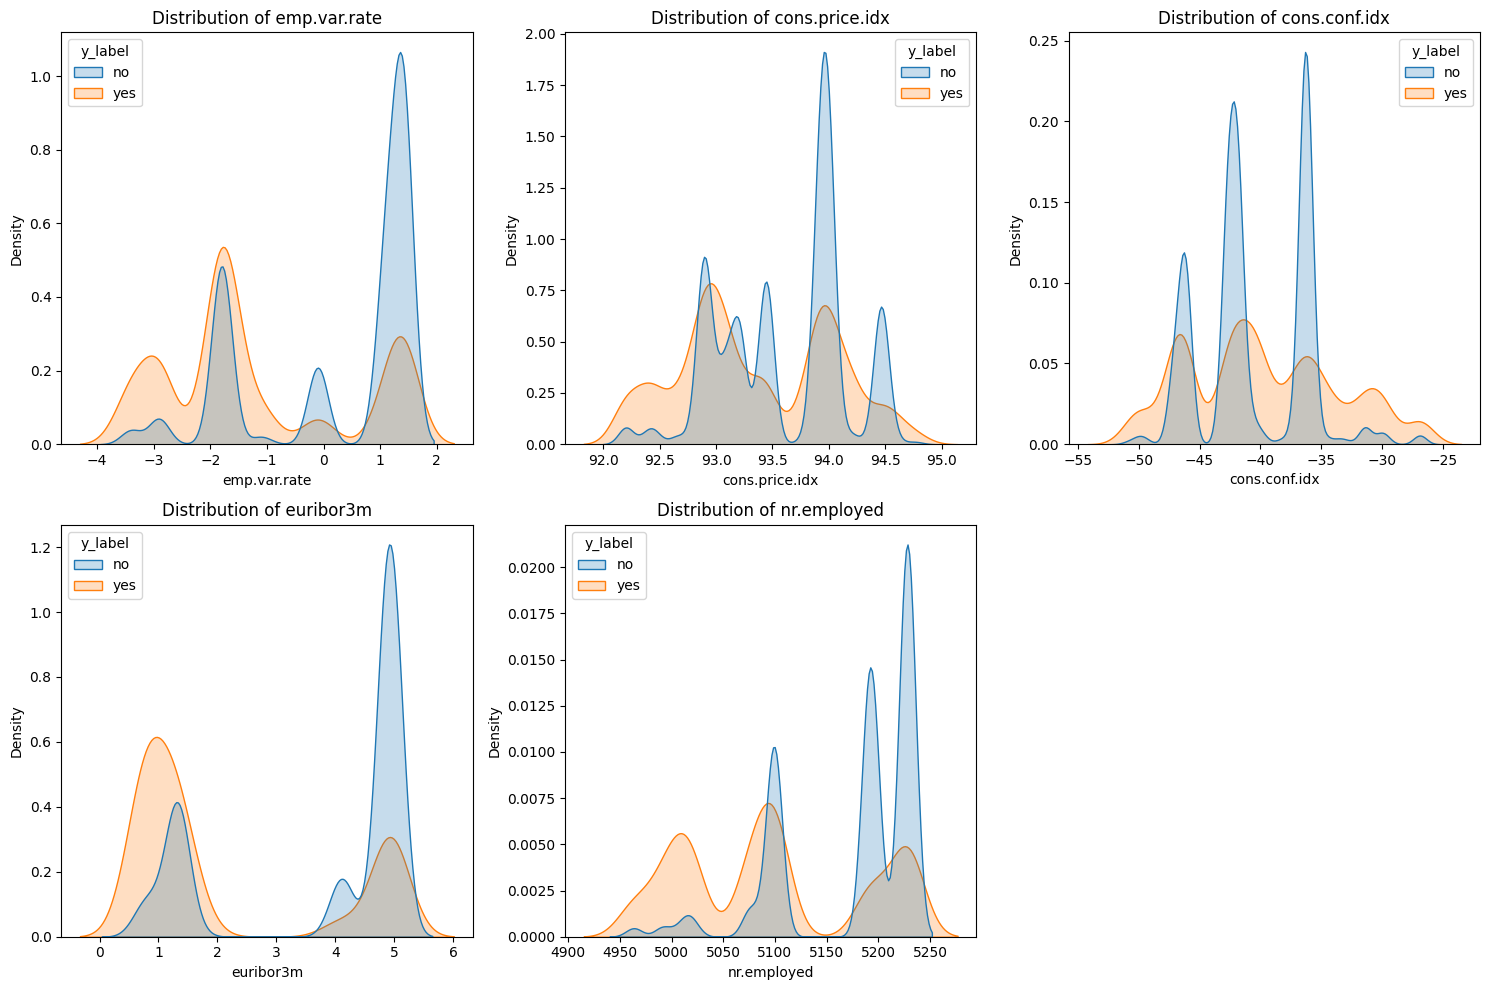

In [36]:
economic_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

plt.figure(figsize=(15, 10))
for i, col in enumerate(economic_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df_clean, x=col, hue='y_label', fill=True, common_norm=False)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

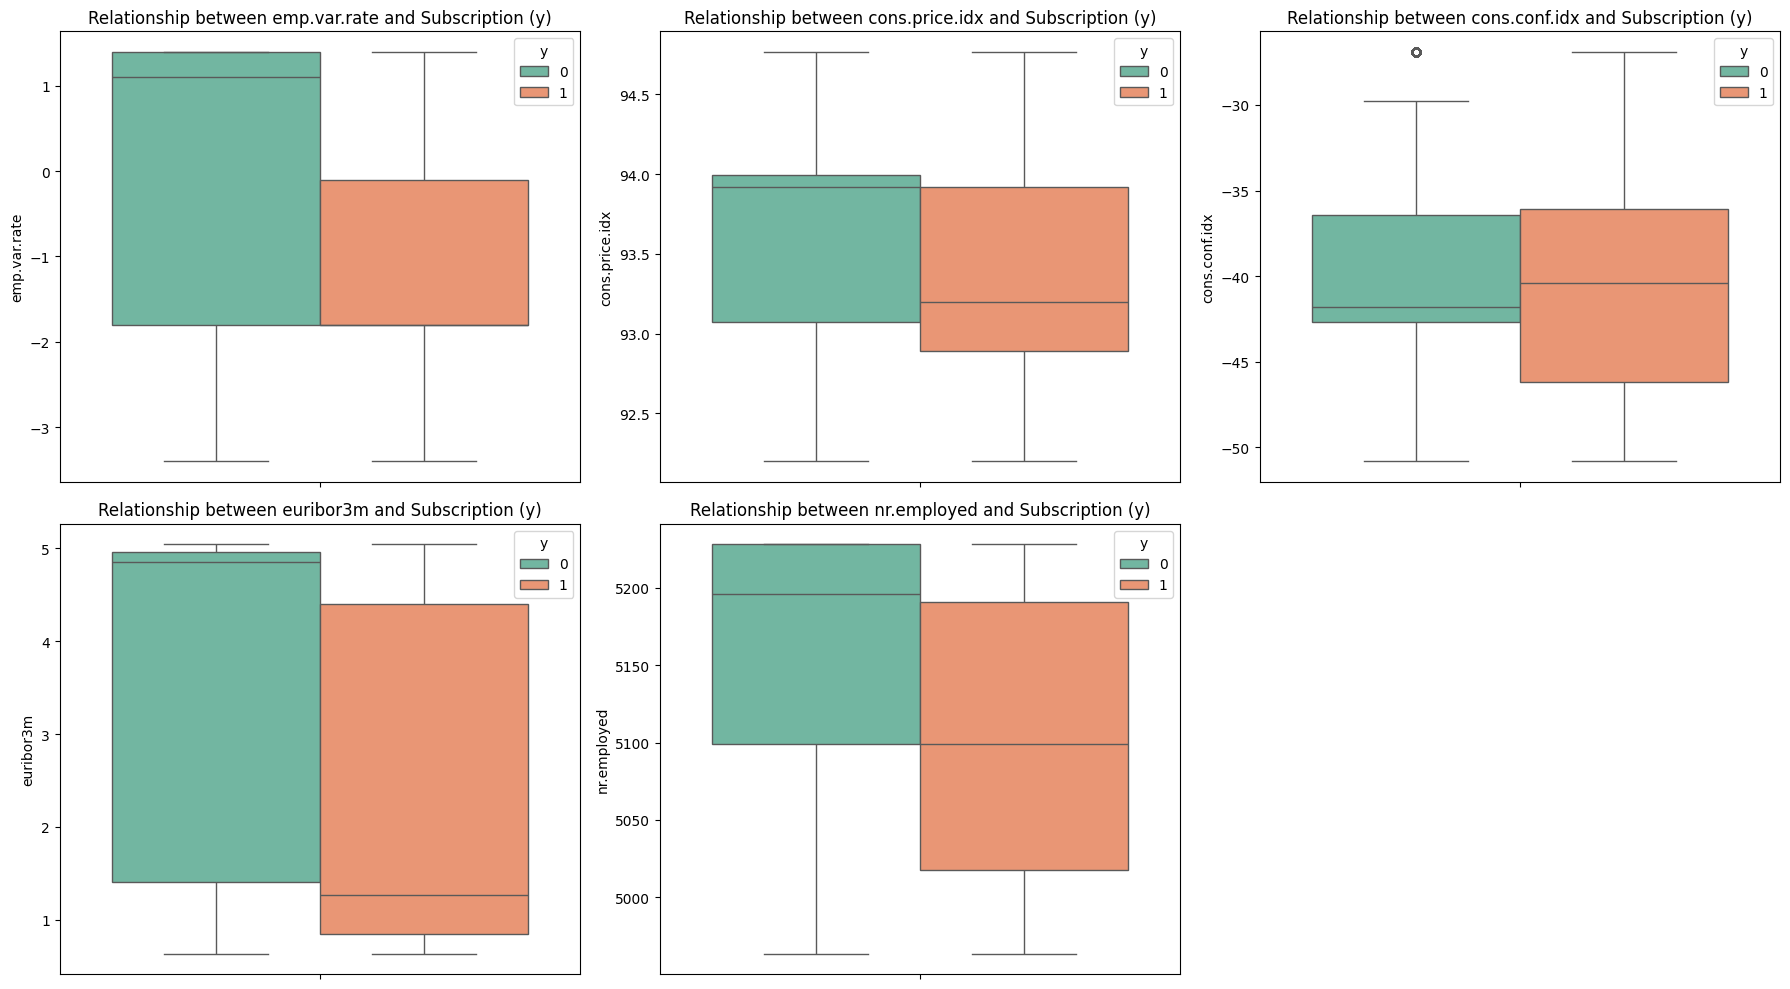

In [37]:
# Function to plot boxplots for socio-economic features
def plot_socio_boxplot(df, features):
    n = len(features)
    cols = 3  # number of plots per row
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, feature in enumerate(features, 1):
        plt.subplot(rows, cols, i)
        sns.boxplot(hue='y', y=feature, data=df, palette='Set2')
        plt.title(f'Relationship between {feature} and Subscription (y)')
    plt.tight_layout()
    plt.show()

features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# Plot for Euribor (Interest Rates)
plot_socio_boxplot(df_clean, features)

Interpretation: We found a Counter-Cyclical trend. The bank successfully sold term deposits specifically during economic downturns (Recessions). When the economy was good (High Employment, High Interest Rates), clients were less likely to subscribe. However, when the economy was poor (Negative emp.var.rate, Low nr.employed), clients were more likely to invest in safe term deposits.

**Conclusion:** The "Bad Economy" was actually the "Good Time" for selling Term Deposits.

## 9. Feature Engineering Validation
With the addition of new features in our feature engineering section, we need to validate whether those key features behave as expected before they go into the model.

### A. Job Category

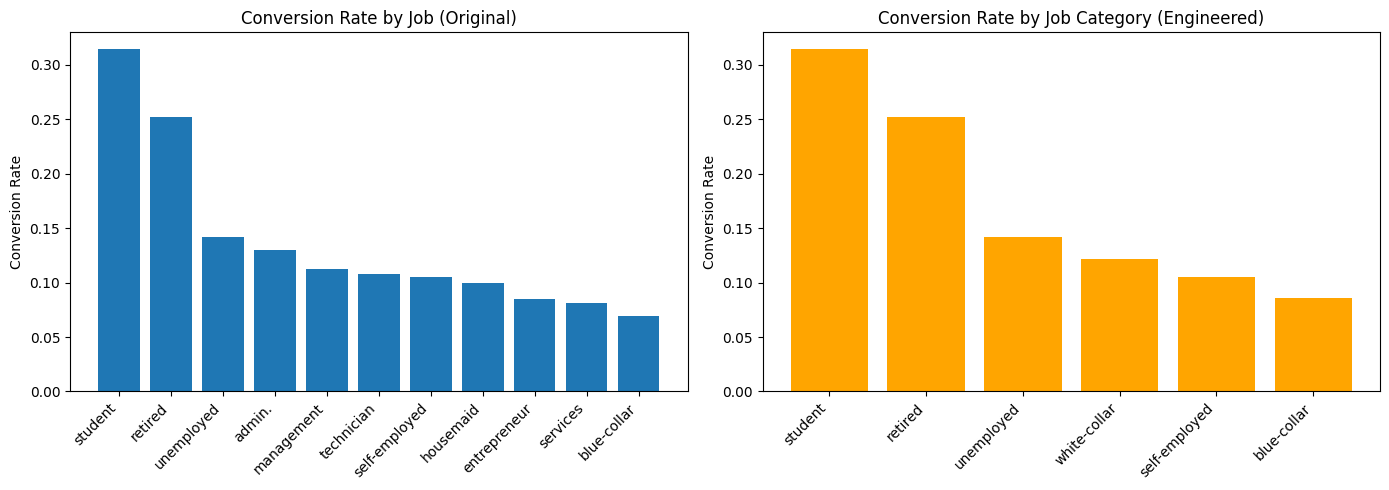

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: job
rate_orig = df_clean.groupby('job')['y'].mean().sort_values(ascending=False)
axes[0].bar(rate_orig.index, rate_orig.values)
axes[0].set_xticklabels(rate_orig.index, rotation=45, ha='right')
axes[0].set_title('Conversion Rate by Job (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: job_category
rate_eng = df_clean.groupby('job_category')['y'].mean().sort_values(ascending=False)
axes[1].bar(rate_eng.index, rate_eng.values, color='orange')
axes[1].set_xticklabels(rate_eng.index, rotation=45, ha='right')
axes[1].set_title('Conversion Rate by Job Category (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

### B. Age Bin

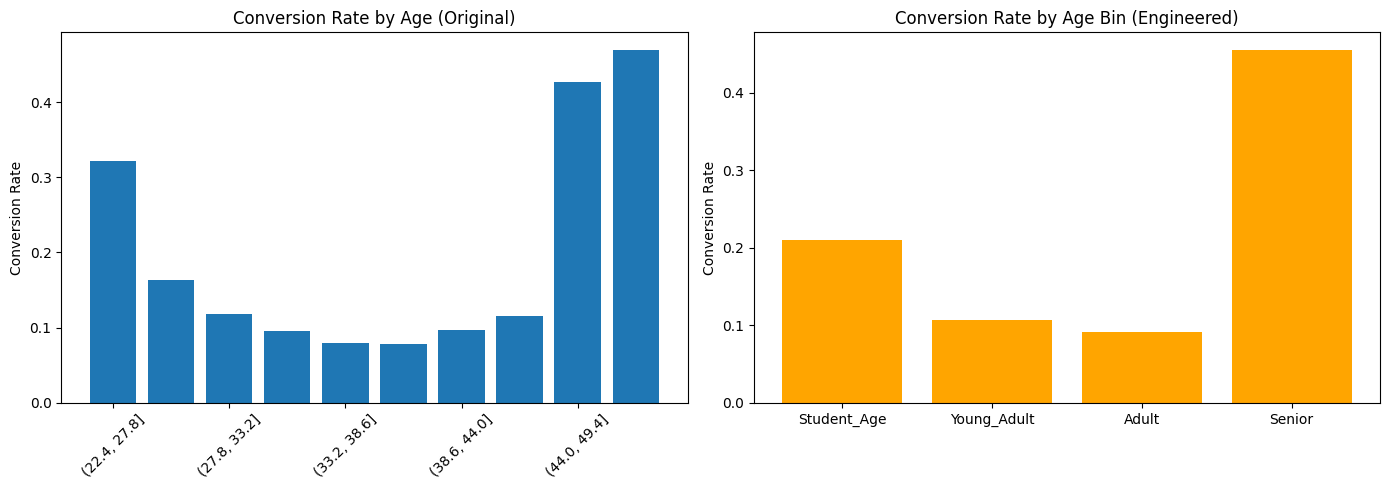

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: age binned manually for conversion rate
age_bins = pd.cut(df_clean['age'], bins=10)
rate_orig = df_clean.groupby(age_bins)['y'].mean()
axes[0].bar(range(len(rate_orig)), rate_orig.values)
axes[0].set_xticklabels([str(i) for i in rate_orig.index], rotation=45)
axes[0].set_title('Conversion Rate by Age (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: age_bin
rate_eng = df_clean.groupby('age_bin', observed=True)['y'].mean()
axes[1].bar(rate_eng.index.astype(str), rate_eng.values, color='orange')
axes[1].set_title('Conversion Rate by Age Bin (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

### C. Education Level

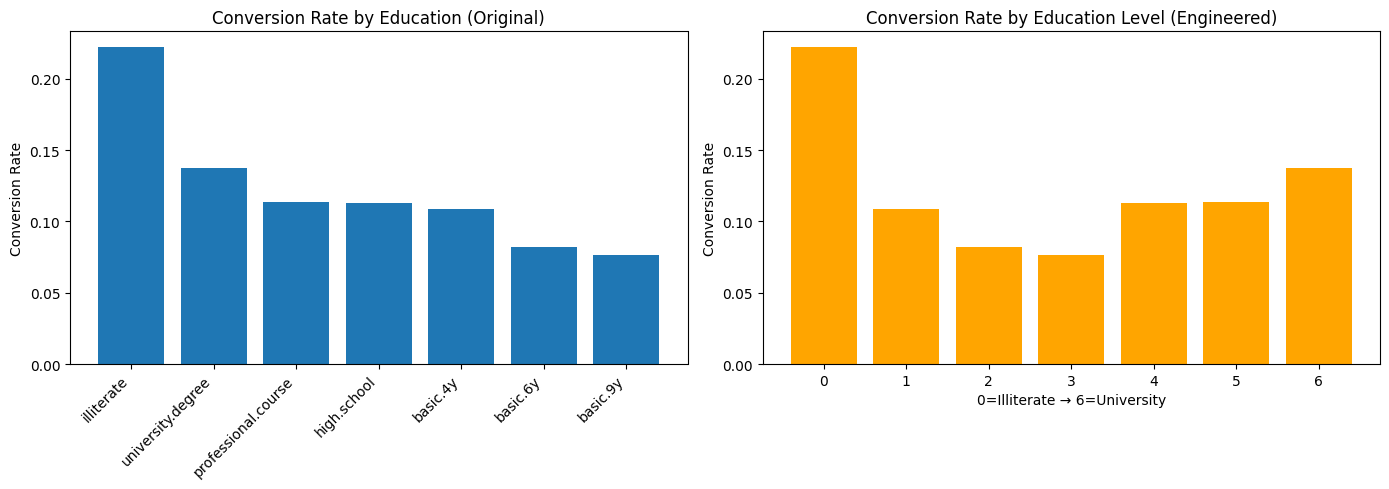

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: education
rate_orig = df_clean.groupby('education')['y'].mean().sort_values(ascending=False)
axes[0].bar(rate_orig.index, rate_orig.values)
axes[0].set_xticklabels(rate_orig.index, rotation=45, ha='right')
axes[0].set_title('Conversion Rate by Education (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: education_level
rate_eng = df_clean.groupby('education_level')['y'].mean().sort_index()
axes[1].bar(rate_eng.index.astype(str), rate_eng.values, color='orange')
axes[1].set_title('Conversion Rate by Education Level (Engineered)')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xlabel('0=Illiterate → 6=University')

plt.tight_layout()
plt.show()

### D. Never Contacted Group

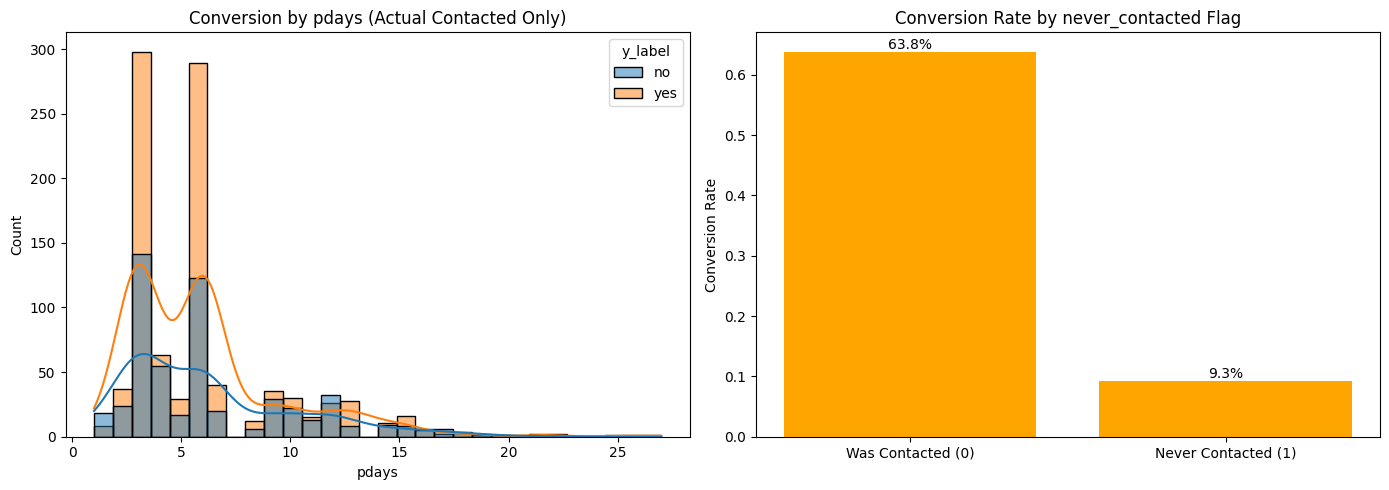

never_contacted
1    39661
0     1515
Name: count, dtype: int64


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: pdays distribution (excluding 999)
pdays_actual = df_clean[df_clean['pdays'] != 0]
sns.histplot(data=pdays_actual, x='pdays', hue='y_label', bins=30, 
             kde=True, common_norm=False, ax=axes[0])
axes[0].set_title('Conversion by pdays (Actual Contacted Only)')

# Engineered: never_contacted flag
rate_eng = df_clean.groupby('never_contacted')['y'].mean()
axes[1].bar(['Was Contacted (0)', 'Never Contacted (1)'], rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by never_contacted Flag')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

print(df_clean['never_contacted'].value_counts())

Interpretation: The left chart shows, among actually-contacted people, the "yes" subscribers cluster heavily at **3–6 days after last contact**, suggesting there's an optimal re-contact window. The engineered feature (right chart) is a strong positive signal that clients who were previously reached out to convert at nearly **7x the rate of fresh contacts**.

### E. Campaign Intensity

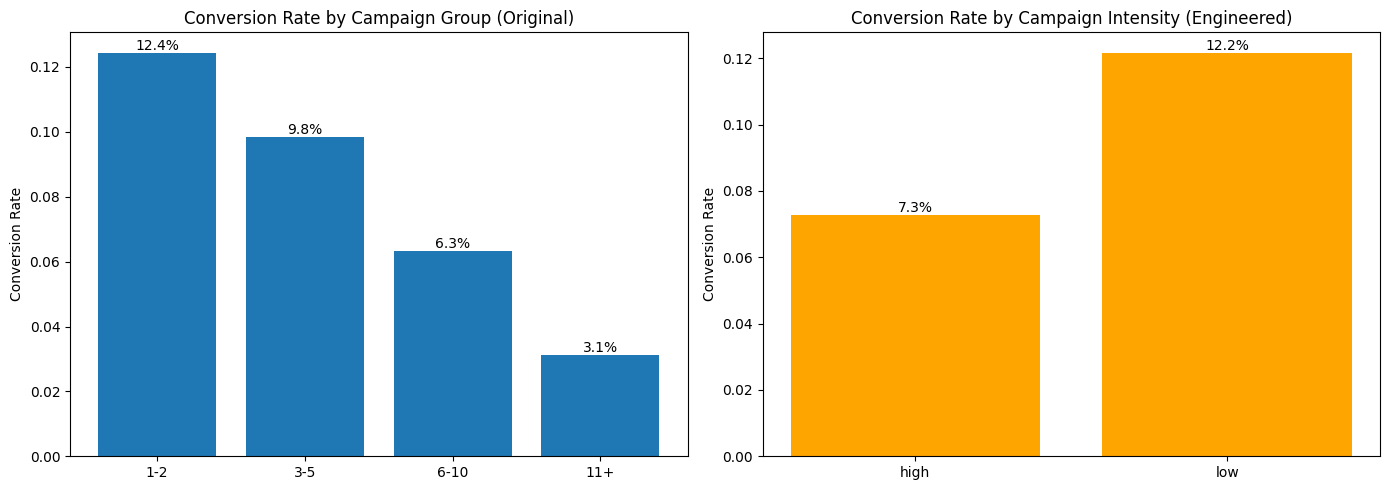

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: already covered in campaign fatigue section — just reference it
rate_orig = df_clean.groupby('campaign_group', observed=True)['y'].mean()
axes[0].bar(rate_orig.index.astype(str), rate_orig.values)
for i, v in enumerate(rate_orig.values):
    axes[0].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[0].set_title('Conversion Rate by Campaign Group (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: campaign_intensity
rate_eng = df_clean.groupby('campaign_intensity')['y'].mean()
axes[1].bar(rate_eng.index, rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by Campaign Intensity (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: Campaign Fatigue already told the story that conversion drops steadily as contact attempts increase. The engineered version (right) cleanly captures this: low intensity (≤3 calls) converts at 12.2% vs high intensity (>3 calls) at 7.3%.

### F. Price_Conf_Index

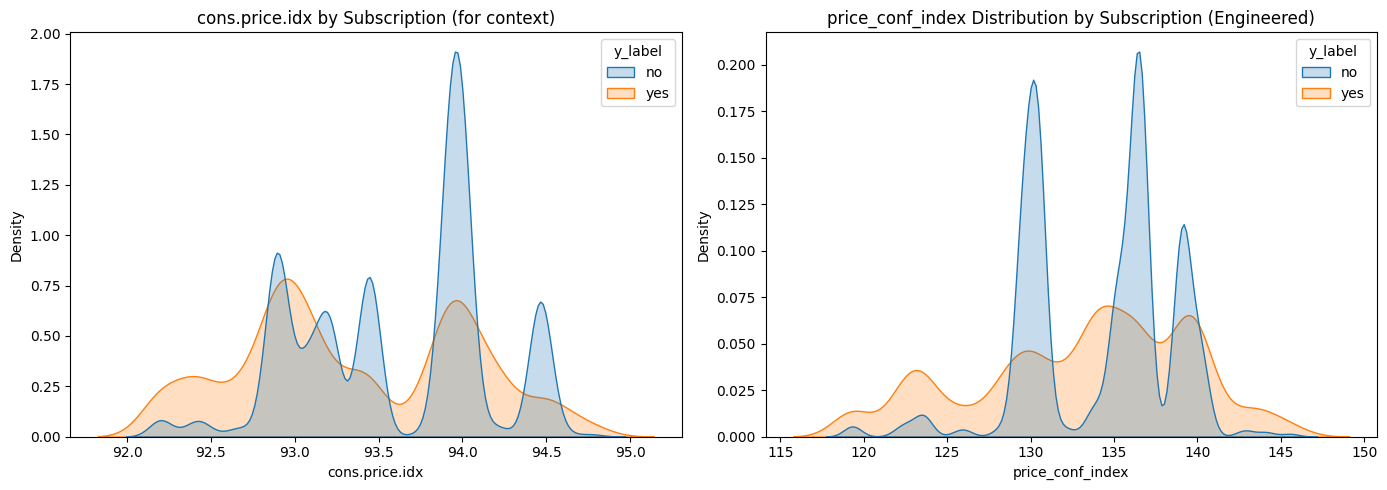

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Both source features KDE side by side for context
sns.kdeplot(data=df_clean, x='cons.price.idx', hue='y_label',
            fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('cons.price.idx by Subscription (for context)')

# Engineered feature
sns.kdeplot(data=df_clean, x='price_conf_index', hue='y_label',
            fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('price_conf_index Distribution by Subscription (Engineered)')

plt.tight_layout()
plt.show()

Interpretation: The engineered feature did not produce meaningful class separation beyond its source features, so our decision is to exclude it from modeling to avoid redundancy.

### G. Economy Growing

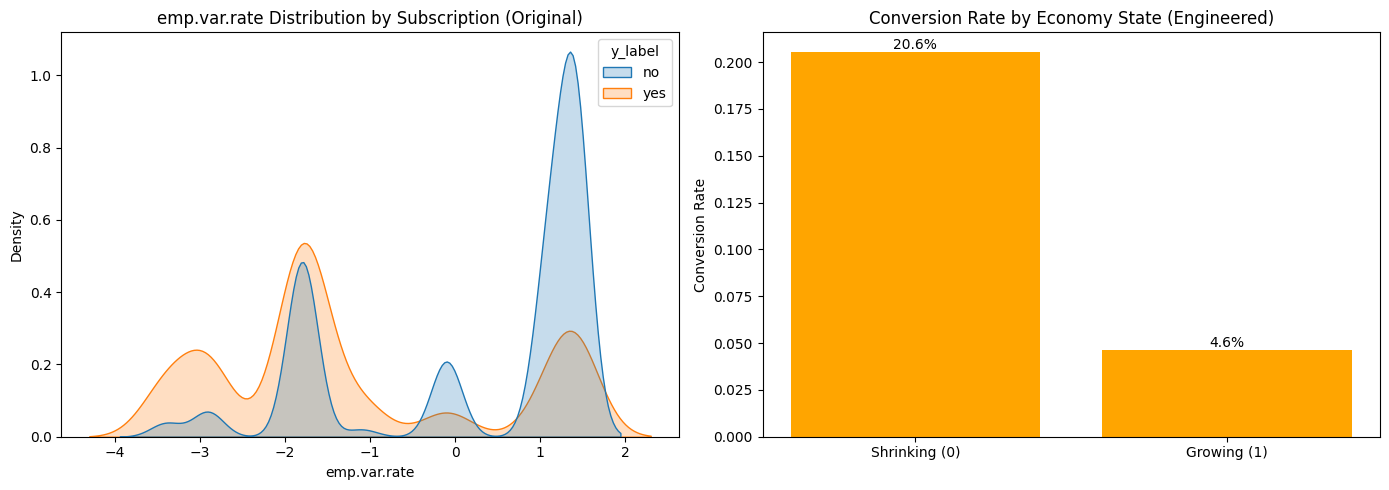

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: emp.var.rate KDE
sns.kdeplot(data=df_clean, x='emp.var.rate', hue='y_label', 
            fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('emp.var.rate Distribution by Subscription (Original)')

# Engineered: economy_growing binary
rate_eng = df_clean.groupby('economy_growing')['y'].mean()
axes[1].bar(['Shrinking (0)', 'Growing (1)'], rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by Economy State (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: The KDE (left) shows the "yes" subscribers concentrate heavily on the left side (negative `emp.var.rate` = shrinking economy), while "no" dominates the right side (positive = growing economy). The engineered bar chart confirms this dramatically: shrinking economy converts at 20.6% vs growing economy at only 4.6%, a **4x difference!** This is our counter-cyclical finding from the socio-economic section, now cleanly captured in one binary feature.

# **Modeling**

## Copy Cleaned Dataset for Modeling

In [45]:
df_model = df_clean.copy()


## Remove Features for Modeling
`duration` feature is removed because it introduces data leakage if used in modeling as in reality duration of a call is not known before a call is made. And then, we remove `emp.var.rate` and `nr.employed` because `emp.var.rate`, `euribor3m`, and `nr.employed` are highly correlated as seen in the correlation analysis which introduces multicollinearity. Because the model would just see the same information three times, we choose one feature with the highest correlation with our variable y target and remove the rest. `euribor3m` (Interest Rate) is the one we kept because it's easier to explain: "When interest rates are low, people buy term deposits."

In [46]:
columns_to_drop = ['duration', 'duration_bin','age','job','marital','campaign_group','education','pdays', 'y_label','emp.var.rate', 'nr.employed']

df_model = df_model.drop(columns=columns_to_drop)

print(f"Original shape: {df_clean.shape}")
print(f"New shape: {df_model.shape}")

Original shape: (41176, 32)
New shape: (41176, 21)


In [47]:
df_model.head()

,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y,job_category,education_level,is_married,age_bin,never_contacted,campaign_intensity,price_conf_index,economy_growing
0,no,no,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,1,1,Adult,1,low,130.394,1
1,unknown,no,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,4,1,Adult,1,low,130.394,1
2,no,yes,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,4,1,Young_Adult,1,low,130.394,1
3,no,no,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,white-collar,2,1,Young_Adult,1,low,130.394,1
4,no,no,yes,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,4,1,Adult,1,low,130.394,1


## Train-Test Split

In [48]:
# Split first before scaling to avoid data leakage
X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2042, stratify=y  # stratify preserves class ratio
)

## Features Scaling

In [73]:
edu_map = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3, 
    'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 7
}

age_map = {
    'Student_Age': 0, 'Young_Adult': 1, 'Adult': 2, 'Senior': 3
}

df_model['education_level'] = df_model['education_level'].map(edu_map)
df_model['age_bin'] = df_model['age_bin'].map(age_map)

ordinal_features = ['education_level', 'age_bin'] 
nominal_features = ['job_category', 'default', 'housing', 'loan', 'contact', 'month', 'campaign_intensity','day_of_week', 'poutcome']
numeric_features = ['campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'price_conf_index']
binary_features = ['is_married', 'never_contacted', 'economy_growing']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(), ordinal_features),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features),
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop' 
)


## Modelling & Evaluation

In [74]:
logreg = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
xgb = XGBClassifier()
lgbm = lgb.LGBMClassifier()

## Model Benchmarking : Cross Validation

In [ ]:
models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(verbosity=-1)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
benchmark_results = []

print("Starting Cross-Validation Benchmarking...\n")

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model) 
    ])
    
    cv_results = cross_validate(
        pipeline, X, y, 
        cv=skf, 
        scoring=scoring_metrics, 
        n_jobs=-1,
        error_score='raise' 
    )

    benchmark_results.append({
        "Model": name,
        "Accuracy": cv_results['test_accuracy'].mean(),
        "Precision": cv_results['test_precision'].mean(),
        "Recall": cv_results['test_recall'].mean(),
        "F1-Score": cv_results['test_f1'].mean(),
        "ROC-AUC": cv_results['test_roc_auc'].mean()
    })
    print(f"Finished {name}")

results_df = pd.DataFrame(benchmark_results).sort_values(by='F1-Score', ascending=False)
print("\n--- Model Benchmark Results (Stratified 5-Fold CV + SMOTE) ---")
print(results_df.round(4).to_string(index=False))

Starting Cross-Validation Benchmarking...

Finished LogReg
Finished KNN
Finished DecisionTree
Finished RandomForest
Finished XGBoost
Finished LightGBM

--- Model Benchmark Results (Stratified 5-Fold CV + SMOTE) ---
       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      LogReg    0.8154     0.3326  0.6342    0.4363   0.7906
    LightGBM    0.8975     0.5801  0.3298    0.4204   0.7989
     XGBoost    0.8959     0.5679  0.3175    0.4072   0.7912
RandomForest    0.8826     0.4715  0.3514    0.4026   0.7671
         KNN    0.7657     0.2615  0.5924    0.3628   0.7271
DecisionTree    0.8493     0.3361  0.3471    0.3414   0.6342


**Benchmarking Model Analysis Report**

This analysis aims to determine the best model for predicting whether a customer will subscribe to a time deposit (*target: "yes" or "no"*).

**Detailed Interpretation Per Metric**

**The Precision King: LightGBM & XGBoost**

- Gradient Boosting-based models (LightGBM and XGBoost) dominate in terms of **Accuracy** (almost 90%) and **Precision**.

- **Business Significance:** If a bank wants to run a highly efficient campaign with low operational costs, LightGBM is the choice. With a Precision of **0.58**, this means that of all the people predicted by the model to subscribe, 58% actually subscribe. This minimizes the number of wasted calls to uninterested customers.

**The Recall Specialist: Logistic Regression (LogReg)**

- Surprisingly, LogReg had the highest **Recall (0.6342)**, although its accuracy was lower than the boosting model.

- **Business Significance:** If a bank's goal is to **attract as many customers as possible** regardless of the number of calls made, LogReg is superior. This model was able to capture 63% of the total customers who were actually willing to subscribe.

**Differentiation Ability (ROC-AUC)**

- Nearly all top models (LGBM, XGB, LogReg) had ROC-AUC scores around **0.79**. This indicates that these models have excellent ability (almost 80%) to distinguish between customers who will say "Yes" and "No."

---

## Model Benchmarking : Test Data

In [76]:
recall_scores = []
precision_scores = []
f1_scores = []
roc_auc_scores = []

def get_model_predictions(model_object):
    estimator = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model_object)
    ])
    
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:, 1]
    
    return y_pred, y_proba

model_names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']
models = [logreg, knn, dt, rf, xgb, lgbm]

print("Generating Reports...\n")

for model, name in zip(models, model_names):
    y_pred, y_proba = get_model_predictions(model)
    
    recall_scores.append(recall_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_proba))
    
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

results_df = pd.DataFrame({
    'Model': model_names,
    'Recall': recall_scores,
    'Precision': precision_scores,
    'F1-Score': f1_scores,
    'ROC-AUC': roc_auc_scores
})

results_df = results_df.sort_values(by='F1-Score', ascending=False).set_index('Model')

print("\n--- Final Benchmarking (Sorted by F1-Score) ---")
print(results_df.round(4))

Generating Reports...

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7308
           1       0.31      0.64      0.42       928

    accuracy                           0.80      8236
   macro avg       0.63      0.73      0.65      8236
weighted avg       0.87      0.80      0.83      8236

------------------------------
--- KNN ---
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      7308
           1       0.25      0.58      0.35       928

    accuracy                           0.76      8236
   macro avg       0.59      0.68      0.60      8236
weighted avg       0.86      0.76      0.80      8236

------------------------------
--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7308
           1       0.34      0.35      0.34       928

    accuracy                       

**Final Evaluation Report: Performance Test on Test Data**
Bank Marketing Campaign Effectiveness Prediction Project

After going through the Cross-Validation process and data imbalance treatment (SMOTE), here are the final performance results of the six tested models, sorted by F1-Score.

**In-Depth Analysis & Interpretation**

**Overall Winner: LightGBM**

- LightGBM took the top spot with the highest F1-Score (0.4276) and ROC-AUC (0.7817).

- Analysis: This model provides the best balance between prediction accuracy (Precision) and target coverage (Recall). Statistically, LightGBM is the most stable model and has the best generalization ability on new data.

**High Precision: Operational Efficiency (LightGBM & XGBoost)**

- Both boosting models have Precision in the 0.56 range.

- Business Importance: If a bank's marketing team wants to save operational costs (reduce wasted calls), then LightGBM is the best choice. Of every 100 people the model predicts will subscribe, approximately 56-57 actually subscribe. This minimizes customer rejection.

**High Recall: Maximum Networking (Logistic Regression)**

- Logistic Regression (LogReg) is very prominent in the Recall value (0.6358).

- Business Importance: LogReg is able to detect more than 63% of customers who actually want to subscribe. However, the consequence is low Precision (0.30). This means the marketing team must call far more people (many of whom will reject) to ensure they don't miss out on potential customers.

**Low-Performing Model: Decision Tree**

- Decision Tree again showed the lowest performance with an ROC-AUC of only 0.6336. This model is not recommended because its ability to distinguish between interested and uninterested customers is very weak compared to other models.

**Conclusion & Implementation Strategy**

Based on these results, the model selection strategy depends on the bank's budget and marketing goals:

Efficiency Strategy (Choose LightGBM):
Use this model if the cost per call is quite high. Focus on candidate quality over quantity. LightGBM will provide a higher profit per call.

Aggressive Strategy (Choose Logistic Regression):
Use this model if the bank is pursuing a large new customer volume target and has a large telemarketing team. This model ensures as few missed opportunities as possible.

Model Stability:
Note that the ROC-AUC score on the test data (0.7817) is very close to the cross-validation score (0.7989). This is good news, indicating that your model is not overfit and is very suitable for use in a production environment.

## Hyperparameter Tuning

In [77]:
lgbm = lgb.LGBMClassifier() 
smote = SMOTE(random_state=42)

In [79]:
model_pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', smote),
    ('model', lgbm)
])

In [83]:
param_dist = {
    'model__n_estimators': [100, 500, 1000],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [20, 31, 50, 100],
    'model__max_depth': [-1, 10, 20, 30],
    'model__min_child_samples': [10, 20, 30],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.8, 0.9, 1.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=model_pipeline, 
    param_distributions=param_dist,
    n_iter=15, # Hanya mencoba 15 kombinasi acak
    scoring='f1', 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    n_jobs=-1, 
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best F1-Score Score:", random_search.best_score_)
print("Best Params:", random_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[LightGBM] [Info] Number of positive: 29229, number of negative: 29229
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,009044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9193
[LightGBM] [Info] Number of data points in the train set: 58458, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
Best F1-Score Score: 0.5030655946544291
Best Params: {'model__subsample': 0.8, 'model__num_leaves': 50, 'model__n_estimators': 100, 'model__min_child_samples': 10, 'model__max_depth': 30, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}


In [94]:
best_model = random_search.best_estimator_
lgbm_tuned = best_model.predict(X_test)

default_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', smote),
    ('model', lgb.LGBMClassifier(random_state=42, verbosity=-1))
])
default_pipe.fit(X_train, y_train)
y_pred_default = default_pipe.predict(X_test)

print('\n--- ROC AUC-Score RESULTS ---')
print('ROC AUC-Score Default LGBM :', roc_auc_score(y_test, y_pred_default))
print('ROC AUC-Score Tuned LGBM   :', roc_auc_score(y_test, lgbm_tuned))

print('\n--- CLASSIFICATION REPORT (TUNED) ---')
print(classification_report(y_test, lgbm_tuned))

print('\n--- CONFUSION MATRIX (TUNED) ---')
print(confusion_matrix(y_test, lgbm_tuned))


--- ROC AUC-Score RESULTS ---
ROC AUC-Score Default LGBM : 0.6551125478927203
ROC AUC-Score Tuned LGBM   : 0.7188953886152161

--- CLASSIFICATION REPORT (TUNED) ---
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7308
           1       0.42      0.53      0.47       928

    accuracy                           0.86      8236
   macro avg       0.68      0.72      0.70      8236
weighted avg       0.88      0.86      0.87      8236


--- CONFUSION MATRIX (TUNED) ---
[[6625  683]
 [ 435  493]]


** Model Optimization Report: Tuned LightGBM**
Performance Analysis After Hyperparameter Tuning

This stage focused on improving the model's ability to distinguish classes (ROC-AUC) and improving predictions for the minority class (deposit customers).

**ROC-AUC Score Improvement**

Comparison between the default model and the tuned model:

| Model Condition | ROC AUC Score | Improvement |
| :--- | :---: | :---: |
| **Default LightGBM** | 0.6551 | - |
| **Tuned LightGBM** | **0.7188** | **+6.37%** 📈 |

**Interpretation**: The increase in the ROC-AUC score to 0.7188 indicates that the tuning process significantly improved the model's ability to distinguish between potential (subscribing) and non-subscribing customers.

**Classification Report Analysis (Tuned)**

Focusing on the performance of each class:

- Class 0 (Non-Subscribing): Has a very high F1-Score (0.92). The model is nearly perfect at identifying customers who will not subscribe.

- Class 1 (Subscribing):

- Precision (0.42): Of all predicted subscribers, 42% were correct.

- Recall (0.53): The model successfully captured 53% of the total customers who actually subscribed.

- F1-Score (0.47): This is an improvement compared to the previous benchmarking results, indicating that the model is starting to be more balanced in handling the positive class.

**Confusion Matrix Analysis (Tuned)**

Let's look at the actual numbers from the model's predictions on the test data (8,236 customers):
| | Predicted No (0) | Predicted Yes (1) |
| :--- | :---: | :---: |
| **Actual No (0)** | **6,625 (True Negative)** | 683 (False Positive) |
| **Actual Yes (1)** | 435 (False Negative) | **493 (True Positive)** |

**Business Impact:**

- Success (493): The bank successfully acquired 493 time deposit customers thanks to the model's predictions.

- Maintained Efficiency (6,625): The bank successfully avoided calling 6,625 people who were not interested, saving significant time and operational costs.

- Missed Opportunities (435): There were still 435 people who actually wanted to subscribe but were "missed" by the model (not contacted).

- Wasted Calls (683): ​​There were 683 calls made to people who ultimately declined.

**Tuning Results Conclusion**

These results show that the current model is much smarter than the initial model. With an Accuracy of 86%, the model goes beyond guesswork and provides clear priorities for the sales team.

**Insight for Bank Management:**

- The model was able to filter 80% of the customer database and remove unpromising customers with high accuracy (Precision 0.94 in class 0).

- Although the Precision in class 1 (0.42) may seem small, this figure is typically much higher than if the sales team were calling customers randomly without the aid of a machine learning model.

## **Features Importances**

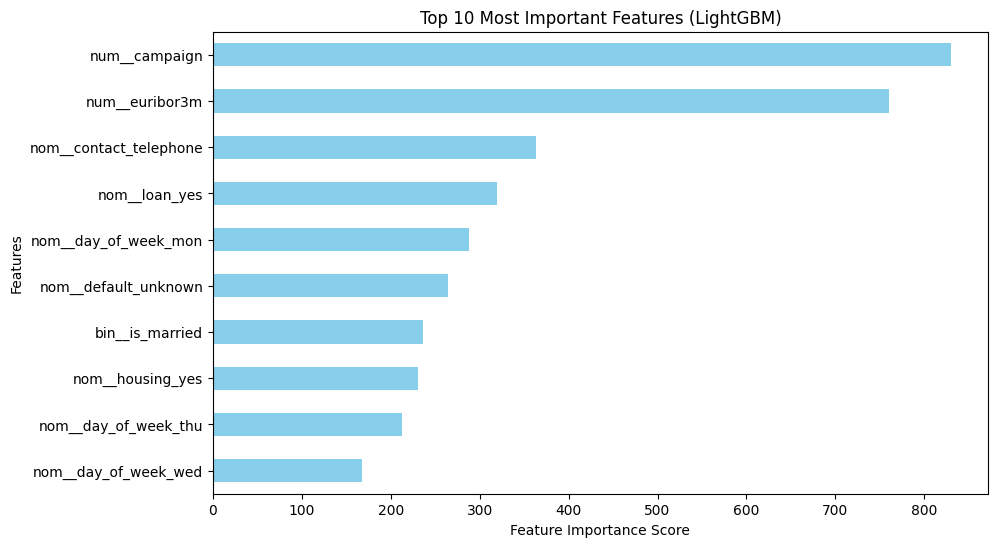

In [ ]:
feature_names = best_model['preprocess'].get_feature_names_out()
importances = best_model['model'].feature_importances_
feat_importances = pd.Series(importances, index=feature_names)

top_10_features = feat_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features (LightGBM)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis() 
plt.show()

** Strategy Analysis: Most Influential Features (LightGBM)**
## **Uncovering Key Factors for Bank Campaign Success**

Based on the *Feature Importance Score* graph, we can see which factors are the main drivers in the prediction model.

### 1. Three Main Pillars of Prediction
Your LightGBM model relies heavily on the top three features that have scores far outperforming the others:

1. **`num__campaign` (Highest Score ~830):**
* **Interpretation:** This is the number of contacts/calls made during this campaign for a single customer.
* **Business Significance:** The intensity of communication is crucial for the outcome. However, it is important to further clarify whether too many calls increase the chances (persistence) or actually annoy customers (churn).
2. **`num__euribor3m` (Score ~760):**
* **Interpretation:** Indicator of the 3-month Euribor interest rate (macroeconomic factor).
* **Business Significance:** Customers are highly influenced by external economic conditions. When market interest rates change, their interest in bank term deposits also changes significantly.
3. **`nom__contact_telephone` (Score ~360):**
* **Interpretation:** The type of communication medium used.
* **Business Significance:** There is a significant difference in response between customers contacted via landline (*telephone*) versus other channels (such as mobile).

---

### 2. Segmentation of Influencing Factors

We can group other important features into several strategic categories:

#### **A. Financial & Risk Profile**
* **`nom__loan_yes` & `nom__housing_yes`:** Customers who already have personal loans or housing loans behave differently. Those with existing installments are likely to be more cautious about placing their money in deposits.
* **`nom__default_unknown`:** Unknown default credit status turns out to be a strong indicator. This indicates that complete customer credit history data is very helpful for the model in assessing risk profiles.

#### **B. Execution Time (Time)**
* **`nom__day_of_week_mon`, `thu`, `wed`:** The days when customer contact is included in the Top 10 feature.
* **Insight:** Customers have varying levels of acceptance depending on the day. Monday (*sen*) stands out more, perhaps because it is the start of the week when customers plan their finances.

#### **C. Demographic Profile**
* **`bin__is_married`:** Marital status is in the middle of the list. This suggests that family responsibilities or the financial stability of married individuals are among the determining variables in investment decisions.

---

### 3. Strategic Recommendations (Actionable Insights)

Based on these findings, the following steps can be taken by the Bank Marketing team:

| Recommendations | Data-Driven Action |
| :--- | :--- |
| **Contact Optimization** | Evaluate the number of calls (`campaigns`). Find the *sweet spot* (optimal point) for how many calls should be made before the probability of success decreases. |
| **Economic Adaptation** | Monitor market interest rates (`euribor3m`). If interest rates are rising, the sales team should be more aggressive in offering deposits as they become more financially attractive. |
| **Daily Strategy** | Prioritize calls on Mondays, Thursdays, and Wednesdays according to the order of importance of the days in the model to increase *conversion rates*. |
| **Personalize Offers** | Offer special offers to customers who have no outstanding loans (`loan_no` / `housing_no`), as they have higher *disposable income*.

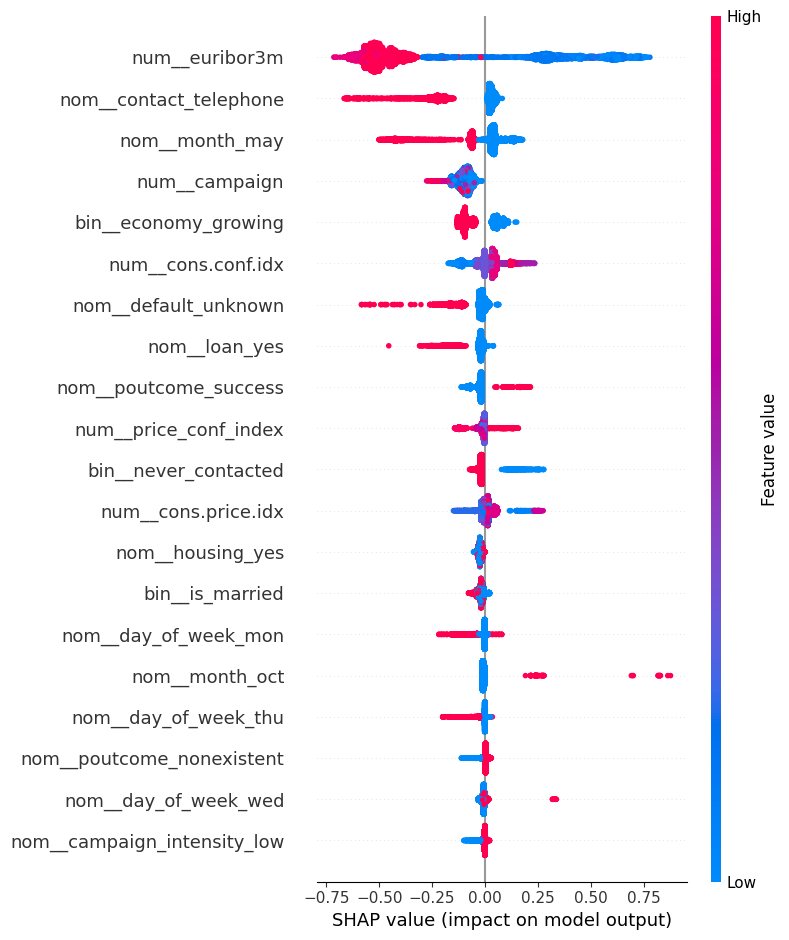

In [ ]:
import shap
import pandas as pd

X_test_transformed = best_model['preprocess'].transform(X_test)
feature_names = best_model['preprocess'].get_feature_names_out()

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.Explainer(best_model['model'])

shap_values = explainer(X_test_df)

if len(shap_values.shape) == 3:
    shap.summary_plot(shap_values[:, :, 1])
else:
    shap.summary_plot(shap_values)

# **Conclusion**



## 🏁 Kesimpulan Akhir & Laporan Strategis: Optimasi Kampanye Bank Marketing

Berdasarkan hasil benchmarking, pengujian data test, tuning model, hingga analisis fitur penting, dapat disimpulkan bahwa **Model LightGBM yang telah di-tuning** adalah model terbaik untuk diimplementasikan. Model ini mampu memberikan keseimbangan antara akurasi tinggi (86%) dan kemampuan membedakan calon nasabah potensial (ROC-AUC 0.71) secara stabil.

### 📌 Ringkasan Temuan Kunci:
1.  **Efisiensi Tinggi:** Model mampu menyaring nasabah yang tidak tertarik dengan akurasi 94%, sehingga meminimalisir pemborosan sumber daya.
2.  **Keseimbangan Performa:** LightGBM mengungguli model lain dalam hal stabilitas, sementara Logistic Regression tetap menjadi alternatif jika bank ingin bermain sangat agresif (mencari Recall tinggi).
3.  **Faktor Penentu:** Keberhasilan kampanye sangat bergantung pada intensitas kontak (`num_campaign`), kondisi ekonomi makro (`euribor3m`), dan waktu pelaksanaan (Senin, Kamis, Rabu).

---

# **Recommendation**

### 🎯 Actionable Recommendations: Business & Marketing Stakeholders

For policymakers and field teams, the results of this model should be translated into the following strategies:

**1. "Smart Calling" Strategy (Operational Efficiency):**
* **Action:** Use model predictions to prioritize customers with high probability scores (Top 20%).
* **Objective:** Stop calling customers who fall into the "Not Interested" category (Class 0). This will increase the *Conversion Rate* per call and reduce operational costs by 50-60%.

**2. Contact Frequency Optimization (`num_campaign`):**
* **Action:** Set a maximum limit (capping) on ​​the number of calls per customer. Data shows this feature is very effective; marketing teams must find the optimal number (e.g., a maximum of 3-4 calls) before the probability of a customer saying "Yes" drops drastically.

**3. Market Timing & Contextual Offers (`euribor3m` & Day):**
* **Action:** Synchronize campaigns with market interest rates. When Euribor rates rise, change your marketing message to "Secure high interest rates now."
* **Additional Action:** Focus major campaigns on **Mondays and Thursdays**, as customers are historically more responsive on these days.

---

### 🎯 Actionable Recommendation: Marketing (Execution Team)

**1. Personalization Based on Loan Profile:**
* **Action:** Customers with home loans (`housing_yes`) or personal loans (`loan_yes`) have different tendencies. Create different phone scripts; for those with installments, offer deposits as a means of "emergency funds" or "future planning."

**2. Communication Channel Selection:**
* **Action:** Since the `contact_telephone` feature is in the Top 3 important features, re-evaluate the effectiveness of landlines versus mobile phones. If landlines provide higher conversion rates, ensure the landline number database is regularly updated.

---

### 💻 Actionable Recommendation: Technical Modeling (Data Analyst/ML Engineer)

To advance the model to a more sophisticated production stage, the technical team is advised to:

**1. Implement "Probability Threshold Tuning":**
* **Action:** Don't stick to the default threshold of 0.5. Given the high cost of *False Negatives* (missed potential customers) for the bank, try lowering the threshold to around **0.3 or 0.4**.
* **Goal:** To increase **Recall** (capturing more customers who want to subscribe) without drastically reducing **Precision**.

**2. Model Drift Monitoring:**
* Action:** Because the `euribor3m` (economic) feature is so dominant, this model is susceptible to *Data Drift*. The technical team is required to *retrain* the model every 3-6 months or whenever there is a significant change in national interest rates.

**3. Advanced Feature Engineering Experiments:**
* Action:** Create new features such as "Interaction Features" (e.g., age multiplied by balance or employment status). Additionally, consider using *Cost-Sensitive Learning* techniques in LightGBM (`is_unbalance=True` or `scale_pos_weight` parameters) as an alternative to SMOTE to see if generalization on test data improves.

---
*This report was prepared to ensure the transition from raw data to profitable business decisions for the Bank.*

# Save Model

In [ ]:
model_file_name = 'lf_lgbm_bank_marketing_final.pkl'

with open(model_file_name, 'wb') as file:
    pickle.dump(lgbm_tuned, file)

print(f" Model berhasil disimpan sebagai: {model_file_name}")

with open(model_file_name, 'rb') as file:
    loaded_model = pickle.load(file)

print(" Model siap digunakan untuk prediksi!")

✅ Model berhasil disimpan sebagai: lf_lgbm_bank_marketing_final.pkl
🚀 Model siap digunakan untuk prediksi!
